# RAG Performance Analysis on TriviaQA

End-to-end retrieval-augmented generation benchmark on the TriviaQA
(`rc`) dataset (wiki entity pages + web search results pooled into one
corpus).  The pipeline is:

1. **Corpus** — load TriviaQA questions plus their Wikipedia entity pages and web search results, pooled into one shared retrieval corpus.
2. **Chunking** — split pages into fixed-size overlapping word windows.
3. **Retrieval** — BM25, TF-IDF, or dense sentence-transformer embeddings.
4. **Generation** — `google/flan-t5-base` (instruction-tuned, deterministic).
5. **Evaluation** — Exact-Match, Token-F1, Recall@k with 95% bootstrap CIs.

Eight experiments are executed end-to-end inside this notebook:

| # | Variable | Fixed |
|---|----------|-------|
| 1 | retriever ∈ {BM25, TF-IDF, Dense} | chunk=128, k=5, instructed prompt |
| 2 | chunk size ∈ {64, 128, 256, 512} | dense, packed to token budget, instructed prompt |
| 3 | k ∈ {1, 3, 5, 10} | dense, chunk=48, instructed prompt |
| 4 | prompt ∈ {concise, instructed} | dense, chunk=128, k=5 |
| 5 | RAG vs No-RAG baseline | dense, chunk=128, k=5, instructed prompt |
| 6 | oracle (answer guaranteed in context) | dense, chunk=128, k=5, instructed prompt |
| 7 | cross-encoder rerank (dense top-50 -> top-5) | chunk=128, k=5, instructed prompt |
| 8 | external distractors in {0, 500, 2000, 5000} | dense, chunk=128, k=5, instructed prompt |

All results are cached as JSON to `results/`; figures land in `figures/`.
Cached embeddings and generation outputs live in `data/cache/` so re-running is cheap.

## 1. Setup — imports and global configuration

All hyperparameters live inside the `config` namespace below.
Changing a value there propagates through the entire pipeline.


In [87]:
import hashlib
import json
import logging
import os
import pickle
import re
import string
import sys
import time
from abc import ABC, abstractmethod
from collections import Counter
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
from tqdm.auto import tqdm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("rag_project")


In [88]:
class config:
    """Central configuration for all RAG experiments."""

    # ── Paths ────────────────────────────────────────────────
    ROOT_DIR    = Path.cwd()
    DATA_DIR    = ROOT_DIR / "data"
    RESULTS_DIR = ROOT_DIR / "results"
    FIGURES_DIR = ROOT_DIR / "figures"
    CACHE_DIR   = ROOT_DIR / "data" / "cache"

    # ── Dataset ──────────────────────────────────────────────
    DATASET_NAME    = "mandarjoshi/trivia_qa"  # HF requires namespace/name
    DATASET_CONFIG  = "rc"      # Open reading-comprehension config:
                                # pools wiki entity pages AND web search
                                # results into the corpus, so retrieval
                                # competes against genuine distractors
                                # rather than only curated evidence.
    DATASET_SPLIT   = "validation"
    NUM_QUESTIONS   = 100       # Fast-iteration default; bump to 500 (or
                                # 1000) for the final report run. Runtime
                                # scales roughly linearly.
    QUESTION_SAMPLE_SEED = 42   # Seeded random sample of NUM_QUESTIONS from the
                                # validation split (replaces the old first-N
                                # slice: a random subset is more representative
                                # of TriviaQA, and the seed keeps it
                                # reproducible). Folded into the corpus cache
                                # key so changing it can't silently reuse a
                                # stale parse.
    NUM_DEV_QUESTIONS = 50      # Held-out dev split (disjoint from the eval
                                # set: the slice right after it in the same
                                # seeded shuffle) used ONLY to choose the
                                # No-RAG no-context prompt, so that choice never
                                # peeks at the eval questions (D6).
    MAX_CORPUS_DOCS = 10000     # With MAX_SEARCH_RESULTS_PER_Q=5, 100 qs
                                # yield ~700-1500 unique docs; this is a
                                # safety ceiling, not a working limit.
                                # Raised from 5000 so the distractor sweep
                                # (Experiment 8) can run at n_dist=5000
                                # without the cap clipping the distractor
                                # mix.
    MAX_SEARCH_RESULTS_PER_Q = 5  # Take only the top-N web hits per qn.
                                  # rc ships 10-50 search results per qn;
                                  # the long tail mostly adds embedding
                                  # cost.  Set to None for no cap.
    NUM_WIKI_DISTRACTORS = 2000   # External Wikipedia articles mixed into
                                  # the retrieval pool as topic-agnostic
                                  # distractors. The in-batch TriviaQA
                                  # pool alone contains the gold pages
                                  # plus only ~1.5k other-question docs,
                                  # so retrieval is easier here than in a
                                  # real open-domain setting. Adding
                                  # generic Wikipedia paragraphs widens
                                  # the noise floor without breaking
                                  # answerability. Set 0 to disable.
                                  # First-run cost on CPU at this size:
                                  # ~100 MB download, ~1-3 min extra
                                  # embedding time per chunk size.
    WIKI_DISTRACTOR_MAX_CHARS = 2000  # Truncate each distractor article
                                      # to its first N characters; keeps
                                      # chunk counts bounded so the
                                      # distractor pool stays modest.

    # ── Chunking ─────────────────────────────────────────────
    CHUNK_SIZES        = [64, 128, 256, 512]
    CHUNK_OVERLAP      = 32
    DEFAULT_CHUNK_SIZE = 128
    EXP3_CHUNK_SIZE    = 48     # Exp 3 sweeps k; at chunk=128 the larger
                               # k values overflow the 1024-token budget
                               # (k=10 ~ 1800 tok) and get truncated, which
                               # confounds the k effect with truncation. We
                               # therefore run Exp 3 at a smaller chunk size
                               # so the whole K_VALUES range fits the budget
                               # untruncated (verified: chunk=48, k=10 ~
                               # 917 tok < 1024).

    # ── Retrieval ────────────────────────────────────────────
    RETRIEVER_TYPES  = ["bm25", "tfidf", "dense"]
    K_VALUES         = [1, 3, 5, 10]
    DEFAULT_K        = 5
    PACK_RETRIEVE_N  = 30      # Exp 2 holds the *context-token budget*
                               # fixed instead of k: it retrieves this many
                               # candidates and greedily packs whole chunks
                               # until the next would exceed MAX_INPUT_TOKENS
                               # (see Generator.pack_to_budget). 30 is enough
                               # to fill the budget even at chunk=64.
    DENSE_MODEL      = "sentence-transformers/all-MiniLM-L6-v2"
    DENSE_BATCH_SIZE = 64

    # ── Embedding-model ablation (Experiment 10) ─────────────
    # Compares dense bi-encoder backbones at fixed chunk/k/prompt.
    # Each entry: label -> (model_name, query_prefix, doc_prefix).
    # Prefixes matter: e5/bge are trained with ASYMMETRIC query/passage
    # instructions and score poorly without them, so a fair comparison
    # must apply each model's recommended prefixes. all-MiniLM uses none.
    # The minilm-l6 row reuses the Experiment-1 dense cache (identical
    # model, no prefix), so it is a cache hit and costs nothing to list.
    EMBEDDING_MODELS = {
        "minilm-l6": ("sentence-transformers/all-MiniLM-L6-v2", "", ""),
        "bge-small": ("BAAI/bge-small-en-v1.5",
                      "Represent this sentence for searching relevant passages: ", ""),
        # Downscaled for now: each extra model adds a cold full-corpus encode
        # (tens of minutes on CPU). Re-enable e5-small to widen the sweep.
        # "e5-small":  ("intfloat/e5-small-v2", "query: ", "passage: "),
    }

    # ── Re-ranker (Experiment 7) ─────────────────────────────
    # Cross-encoder applied on top of a dense first-stage retrieval. The
    # base retriever returns RERANK_TOP_N candidates; the cross-encoder
    # scores every (query, chunk) pair and selects the top-k for the
    # generator. This is the canonical "advanced RAG" two-stage setup
    # (Gao et al. [44]).
    RERANK_MODEL      = "cross-encoder/ms-marco-MiniLM-L-6-v2"
    RERANK_TOP_N      = 50
    RERANK_BATCH_SIZE = 64
    # First-stage bi-encoder feeding the cross-encoder. Defaults to the
    # strongest embedding model from Experiment 10 (e5-small) so the reranker
    # sits on top of the best available candidates rather than MiniLM. Re-uses
    # the Exp-10 e5 embedding cache; the prefixes MUST match the Exp-10 e5
    # entry so the cached document embeddings stay valid.
    RERANK_BASE_MODEL        = "intfloat/e5-small-v2"
    RERANK_BASE_QUERY_PREFIX = "query: "
    RERANK_BASE_DOC_PREFIX   = "passage: "

    # ── Distractor sweep (Experiment 8) ──────────────────────
    # Re-runs the RAG arm at multiple distractor counts so we can see how
    # retrieval degrades as the topic-agnostic noise floor rises. The
    # No-RAG arm is corpus-independent, so we reuse it from Experiment 5.
    DISTRACTOR_SWEEP_VALUES = [0, 500, 2000, 5000]

    # ── Controlled distraction (Experiment 9) ───────────────
    # Hold retrieval recall at 1 (gold chunk always present) and
    # vary the number of non-gold distractor chunks beside it.
    DISTRACTION_N_VALUES = [0, 1, 2, 4, 8]

    # ── Generation ───────────────────────────────────────────
    GENERATOR_MODEL      = "google/flan-t5-base"
    MAX_INPUT_TOKENS     = 1024   # Raised from 512: at chunk=128, k>=3
                                  # already overflows a 512-token budget
                                  # (~170 tok/chunk + ~100 tok prompt
                                  # overhead), so the encoder receives an
                                  # identically-truncated input for k=3/5/10
                                  # and Exp 3 cannot resolve k effects.
                                  # Flan-T5 tolerates >=1024 input fine
                                  # in practice. NB: prompts that still
                                  # exceed the budget are *middle*-truncated
                                  # by the Generator (see _truncate_middle):
                                  # the question repeats and the "Short
                                  # answer:" cue are preserved, only the
                                  # context body is shortened.
                                  # Re-runs after this change require
                                  # clearing data/cache/generation_cache.json
                                  # so prompts aren't re-served from the
                                  # earlier 512-token cache.
    MAX_NEW_TOKENS       = 32       # answers are almost always <10 tokens
    GENERATOR_BATCH_SIZE = 16
    USE_GENERATION_CACHE = False  # When True, generated answers are cached to
                                  # data/cache/generation_cache.json keyed by
                                  # the rendered prompt, so re-runs replay the
                                  # cached outputs and finish in seconds.
                                  # Default False so every run actually executes
                                  # the generator (greedy decoding is
                                  # deterministic, so the numbers are identical
                                  # either way). Flip to True for fast plot-only
                                  # iteration once the results JSON exist.

    # ── Evaluation ───────────────────────────────────────────
    BOOTSTRAP_SAMPLES = 1000
    RANDOM_SEED       = 42

    # ── Prompting ────────────────────────────────────────────
    PROMPT_TEMPLATES = {
        # NB: both RAG templates repeat the question *before* and *after*
        # the context. T5 truncation chops from the end, so a question
        # only at the end can be cut off; the leading copy keeps it
        # visible under aggressive truncation while the trailing
        # "Answer:" / "Short answer:" still serves as the generation cue.
        # As of the middle-truncation fix in `Generator._truncate_middle`,
        # the trailing question/cue is also preserved verbatim — only the
        # `{context}` body is shortened when the prompt exceeds budget.
        #
        # The instructed template's leading sentence is intentionally
        # short (~7 tokens) so concise and instructed are length-matched
        # to within ~10 tokens — that way Exp 4 measures the instruction
        # signal itself, not the cost of displaced context.
        "concise": (
            "Question: {question}\n\n"
            "Context:\n{context}\n\n"
            "Question: {question}\n"
            "Answer:"
        ),
        "instructed": (
            "Answer with a short phrase.\n\n"
            "Question: {question}\n\n"
            "Context:\n{context}\n\n"
            "Question: {question}\n"
            "Short answer:"
        ),
        # The no_context template is the canonical no-RAG (parametric)
        # cue. We adopt T5's "Q:/A:" shape because the prompt-robustness
        # sweep in section 14 ("Prompt sensitivity of the No-RAG
        # baseline") showed it produced the highest EM among four
        # reasonable alternatives. The spread across alternatives is
        # only ~5pp, so the No-RAG arm should be read as a robust
        # parametric *floor* — Flan-T5-base genuinely lacks the
        # TriviaQA-grade facts — not as a measure of its specific
        # knowledge.
        "no_context": "Q: {question}\nA:",
    }
    DEFAULT_PROMPT = "instructed"


for _d in [config.DATA_DIR, config.RESULTS_DIR, config.FIGURES_DIR, config.CACHE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

print("Working directory:", config.ROOT_DIR)
print("Results dir:      ", config.RESULTS_DIR)
print("Figures dir:      ", config.FIGURES_DIR)
print("Cache dir:        ", config.CACHE_DIR)


Working directory: c:\Users\Filip\Documents\ml-project\RAG_ML
Results dir:       c:\Users\Filip\Documents\ml-project\RAG_ML\results
Figures dir:       c:\Users\Filip\Documents\ml-project\RAG_ML\figures
Cache dir:         c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache


## 2. Corpus loading — TriviaQA (`rc`)

We use the `rc` configuration of TriviaQA (Lewis et al. 2020 [42];
Joshi et al. 2017), which pairs each trivia question with **two** evidence
sources: curated Wikipedia entity pages **and** noisy web search results.
We pool both into a single shared retrieval corpus so the retriever has
to find the answer among genuine distractors rather than only hand-picked
evidence.

* Entity pages and web hits from all sampled questions are pooled into one
  shared retrieval corpus, so each question's relevant pages compete against
  many distractors (a realistic setting). The web-hit count per question is
  capped by `config.MAX_SEARCH_RESULTS_PER_Q`.
* Each document carries a `source` field (`"wiki"` or `"web"`) so per-source
  analyses are possible.
* The raw dataset is cached as a pickle file so subsequent runs skip the download.
* Each corpus document has the uniform schema `{doc_id, title, text, source}`.

In [89]:
def load_triviaqa(
    num_questions: int = config.NUM_QUESTIONS,
    cache_path: Optional[Path] = None,
) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    """Load TriviaQA and return (questions, corpus_docs)."""
    if cache_path is None:
        # Include parsing-relevant config so changing the search cap or
        # the distractor count doesn't silently re-use a stale parsed corpus.
        web_cap = getattr(config, "MAX_SEARCH_RESULTS_PER_Q", None)
        web_tag = "all" if web_cap is None else str(web_cap)
        wiki_n  = int(getattr(config, "NUM_WIKI_DISTRACTORS", 0) or 0)
        seed    = int(getattr(config, "QUESTION_SAMPLE_SEED", 42))
        cache_path = (
            config.CACHE_DIR
            / f"triviaqa_{config.DATASET_CONFIG}_n{num_questions}_w{web_tag}_wd{wiki_n}_s{seed}.pkl"
        )

    if cache_path.exists():
        logger.info("Loading TriviaQA from cache: %s", cache_path)
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    logger.info(
        "Downloading TriviaQA (%s, %s split, first %d questions)…",
        config.DATASET_CONFIG, config.DATASET_SPLIT, num_questions,
    )
    from datasets import load_dataset
    ds = load_dataset(
        config.DATASET_NAME, config.DATASET_CONFIG, split=config.DATASET_SPLIT,
    )

    questions: List[Dict[str, Any]] = []
    corpus_docs: List[Dict[str, Any]] = []
    seen_keys: set = set()

    # (source_name, section_key_in_example, text_field_in_section)
    SOURCE_SPECS = [
        ("wiki", "entity_pages",   "wiki_context"),
        ("web",  "search_results", "search_context"),
    ]
    MIN_DOC_CHARS = 50

    # Seeded random sample (was: a first-N slice). A random subset of the
    # validation split is more representative of TriviaQA than its first rows;
    # the seed keeps it reproducible and is folded into the cache key above.
    seed   = int(getattr(config, "QUESTION_SAMPLE_SEED", 42))
    n_take = min(num_questions, len(ds))
    subset = ds.shuffle(seed=seed).select(range(n_take))

    cap_reached = False
    for idx, example in enumerate(tqdm(subset, desc="Parsing TriviaQA")):
        answers = _extract_answers(example)
        if not answers:
            continue
        questions.append({
            "qid":      example.get("question_id", str(idx)),
            "question": example["question"],
            "answers":  answers,
        })

        if cap_reached:
            continue  # keep question, but stop adding evidence

        web_cap = getattr(config, "MAX_SEARCH_RESULTS_PER_Q", None)
        for src, section_key, text_field in SOURCE_SPECS:
            section = example.get(section_key) or {}
            titles    = section.get("title")    or []
            texts     = section.get(text_field) or []
            filenames = section.get("filename") or []
            n         = max(len(titles), len(texts), len(filenames))
            if src == "web" and web_cap is not None:
                n = min(n, web_cap)

            for i in range(n):
                title    = titles[i]    if i < len(titles)    else ""
                text     = texts[i]     if i < len(texts)     else ""
                filename = filenames[i] if i < len(filenames) else ""
                text = (text or "").strip()
                if len(text) < MIN_DOC_CHARS:
                    continue
                dedup_id = filename or title
                if not dedup_id:
                    continue
                dedup_key = (src, dedup_id)
                if dedup_key in seen_keys:
                    continue
                seen_keys.add(dedup_key)
                corpus_docs.append({
                    "doc_id": f"{src}_{len(corpus_docs):06d}",
                    "title":  title or f"(untitled {src})",
                    "text":   text,
                    "source": src,
                })
                if len(corpus_docs) >= config.MAX_CORPUS_DOCS:
                    cap_reached = True
                    break
            if cap_reached:
                break
        if cap_reached:
            logger.info("Reached MAX_CORPUS_DOCS=%d — no more docs will be added.",
                        config.MAX_CORPUS_DOCS)

    # External Wikipedia distractors (Issue 2.4 mitigation).
    wiki_n = int(getattr(config, "NUM_WIKI_DISTRACTORS", 0) or 0)
    if wiki_n > 0 and not cap_reached:
        max_chars = int(getattr(config, "WIKI_DISTRACTOR_MAX_CHARS", 2000))
        budget = max(0, config.MAX_CORPUS_DOCS - len(corpus_docs))
        target = min(wiki_n, budget)
        distractors = _load_wiki_distractors(target, max_chars=max_chars)
        for d in distractors:
            dedup_key = ("wiki_distractor", d["title"])
            if dedup_key in seen_keys:
                continue
            seen_keys.add(dedup_key)
            d = {**d, "doc_id": f"wiki_distractor_{len(corpus_docs):06d}"}
            corpus_docs.append(d)
            if len(corpus_docs) >= config.MAX_CORPUS_DOCS:
                logger.info("Reached MAX_CORPUS_DOCS=%d while adding wiki distractors.",
                            config.MAX_CORPUS_DOCS)
                break

    n_wiki = sum(1 for d in corpus_docs if d["source"] == "wiki")
    n_web  = sum(1 for d in corpus_docs if d["source"] == "web")
    n_dist = sum(1 for d in corpus_docs if d["source"] == "wiki_distractor")
    logger.info(
        "Loaded %d questions and %d corpus documents (%d wiki + %d web + %d distractor).",
        len(questions), len(corpus_docs), n_wiki, n_web, n_dist,
    )

    result = (questions, corpus_docs)
    with open(cache_path, "wb") as f:
        pickle.dump(result, f)
    logger.info("Saved to cache: %s", cache_path)

    return result


def _extract_answers(example: Dict[str, Any]) -> List[str]:
    """Return all gold answer strings from a TriviaQA example."""
    ans_dict = example.get("answer", {})
    if not ans_dict:
        return []

    answers: List[str] = []
    value = ans_dict.get("value", "")
    if value:
        answers.append(value)
    answers.extend([a for a in (ans_dict.get("aliases") or []) if a])
    answers.extend([a for a in (ans_dict.get("normalized_aliases") or []) if a])

    seen: set = set()
    unique: List[str] = []
    for a in answers:
        low = a.lower()
        if low not in seen:
            seen.add(low)
            unique.append(a)
    return unique


def _load_wiki_distractors(
    n: int,
    max_chars: int = 2000,
    dataset_name: str = "wikimedia/wikipedia",
    dataset_config: str = "20231101.simple",
    seed: int = 42,
) -> List[Dict[str, Any]]:
    """Load N Wikipedia articles to use as external (topic-agnostic) distractors.

    Uses Simple English Wikipedia by default (~200k articles, ~100 MB download)
    so the corpus picks up a realistic open-domain noise floor without paying
    for the full English Wikipedia. Returns docs with source='wiki_distractor';
    each article is truncated to `max_chars` characters so chunk counts stay
    bounded.
    """
    if n <= 0:
        return []
    try:
        from datasets import load_dataset
        logger.info(
            "Loading %d Wikipedia distractor articles (%s / %s)…",
            n, dataset_name, dataset_config,
        )
        ds = load_dataset(dataset_name, dataset_config, split="train")
        # Deterministic sample. shuffle() on the small Simple-English subset
        # is fast; on full English Wikipedia, switch to streaming if needed.
        n_take = min(n, len(ds))
        ds = ds.shuffle(seed=seed).select(range(n_take))

        distractors: List[Dict[str, Any]] = []
        for ex in ds:
            text  = (ex.get("text") or "").strip()
            title = (ex.get("title") or "").strip()
            if not text or len(text) < 50:
                continue
            distractors.append({
                "doc_id": "",  # assigned by caller (depends on insertion order)
                "title":  title or "(Wikipedia)",
                "text":   text[:max_chars],
                "source": "wiki_distractor",
            })
        logger.info("Prepared %d wiki distractor documents.", len(distractors))
        return distractors
    except Exception as e:
        logger.warning(
            "Could not load wiki distractors (%s); proceeding without them.", e,
        )
        return []


def load_dev_questions(
    n_dev: int = config.NUM_DEV_QUESTIONS,
    eval_n: int = config.NUM_QUESTIONS,
    cache_path: Optional[Path] = None,
) -> List[Dict[str, Any]]:
    """Load a dev set of questions DISJOINT from the eval set (D6).

    Used only to select the No-RAG no-context prompt, so the selection never
    peeks at the eval questions. Uses the SAME seeded shuffle as the eval set
    (load_triviaqa) and takes the slice immediately AFTER the eval slice, so
    the two are guaranteed disjoint. No corpus is built: the No-RAG baseline
    ignores retrieval, so only (question, answers) are needed.
    """
    if n_dev <= 0:
        return []
    seed = int(getattr(config, "QUESTION_SAMPLE_SEED", 42))
    if cache_path is None:
        cache_path = (
            config.CACHE_DIR
            / f"triviaqa_dev_{config.DATASET_CONFIG}_n{eval_n}_dev{n_dev}_s{seed}.pkl"
        )
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    from datasets import load_dataset
    logger.info("Loading %d held-out dev questions (disjoint from eval)…", n_dev)
    ds = load_dataset(
        config.DATASET_NAME, config.DATASET_CONFIG, split=config.DATASET_SPLIT,
    )
    ds = ds.shuffle(seed=seed)  # same permutation as the eval slice
    start = min(eval_n, len(ds))
    end   = min(eval_n + n_dev, len(ds))
    dev: List[Dict[str, Any]] = []
    for idx in range(start, end):
        ex = ds[idx]
        answers = _extract_answers(ex)
        if not answers:
            continue
        dev.append({
            "qid":      ex.get("question_id", str(idx)),
            "question": ex["question"],
            "answers":  answers,
        })
    with open(cache_path, "wb") as f:
        pickle.dump(dev, f)
    logger.info("Loaded %d dev questions (cached to %s).", len(dev), cache_path)
    return dev


## 3. Chunking

Chunking is one of the most impactful decisions in a RAG pipeline (Gao et al. 2024 [44]).

**Fixed-size word chunking with overlap** — split a document's text into
windows of W words, stepping by (W − overlap) words each time. Overlap
prevents an answer that straddles a chunk boundary from being lost.

Every chunk has schema `{chunk_id, doc_id, title, text, chunk_idx}`.


In [90]:
def chunk_corpus(
    corpus_docs: List[Dict],
    chunk_size: int = config.DEFAULT_CHUNK_SIZE,
    overlap: int = config.CHUNK_OVERLAP,
) -> List[Dict]:
    """Chunk every document in corpus_docs into fixed-size word windows."""
    chunks: List[Dict] = []
    for doc in corpus_docs:
        chunks.extend(_word_chunks(doc, chunk_size, overlap))
    return chunks


def _word_chunks(doc: Dict, chunk_size: int, overlap: int) -> List[Dict]:
    """Split doc['text'] into overlapping word windows."""
    words = doc["text"].split()
    if not words:
        return []

    effective_overlap = min(overlap, chunk_size - 1)
    step = chunk_size - effective_overlap

    chunks: List[Dict] = []
    start = 0
    idx = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append({
            "chunk_id":  f"{doc['doc_id']}_c{idx:04d}",
            "doc_id":    doc["doc_id"],
            "title":     doc["title"],
            "text":      " ".join(words[start:end]),
            "chunk_idx": idx,
        })
        start += step
        idx   += 1
        if end == len(words):
            break
    return chunks


def chunk_stats(chunks: List[Dict]) -> Dict:
    """Return descriptive statistics about chunk lengths (in words)."""
    lengths = [len(c["text"].split()) for c in chunks]
    arr = np.array(lengths, dtype=float)
    return {
        "n_chunks":     len(chunks),
        "mean_words":   float(arr.mean()),
        "std_words":    float(arr.std()),
        "min_words":    int(arr.min()),
        "max_words":    int(arr.max()),
        "median_words": float(np.median(arr)),
    }


## 4. Retrieval backends

Three backends with a uniform interface (`build(chunks)`, `retrieve(query, k)`):

* **BM25** — `rank-bm25` Okapi BM25. Indexes a token stream produced by
  `_lexical_tokenize` (lowercase, accent-strip, regex `\b\w\w+\b`).
* **TF-IDF** — `sklearn.feature_extraction.text.TfidfVectorizer` configured
  to consume the *same* `_lexical_tokenize` token stream as BM25, unigrams
  only, sublinear TF, no DF filtering. So BM25 vs TF-IDF differs **only**
  in the scoring function — not in tokenisation, vocabulary, or n-gram order.
* **Dense** — `sentence-transformers/all-MiniLM-L6-v2` (22 M parameters,
  384-dim L2-normalised embeddings; cosine = dot product). Embeddings are
  cached to disk and re-used across experiments.


In [91]:
# Shared lexical tokenizer used by both BM25 and TF-IDF so the two sparse
# retrievers see *identical* token streams. The only remaining difference
# between BM25 and TF-IDF in this notebook is the scoring function itself.
_LEXICAL_TOKEN_RE = re.compile(r"(?u)\b\w\w+\b")


def _lexical_tokenize(text: str) -> List[str]:
    """Lowercase, strip accents, then extract `\b\w\w+\b` tokens."""
    import unicodedata
    norm = unicodedata.normalize("NFKD", text)
    norm = "".join(c for c in norm if not unicodedata.combining(c))
    return _LEXICAL_TOKEN_RE.findall(norm.lower())


class BaseRetriever(ABC):
    """Common interface for all retrieval backends."""
    name: str = "base"

    @abstractmethod
    def build(self, chunks: List[Dict]) -> None:
        """Index the provided chunks."""

    @abstractmethod
    def retrieve(self, query: str, k: int) -> List[Dict]:
        """Return up to k most-relevant chunks for *query*."""

    def batch_retrieve(self, queries: List[str], k: int) -> List[List[Dict]]:
        return [self.retrieve(q, k) for q in tqdm(queries, desc=f"{self.name} retrieval")]


class BM25Retriever(BaseRetriever):
    """Sparse retrieval using Okapi BM25 over the shared lexical tokenizer."""
    name = "bm25"

    def __init__(self):
        self._index = None
        self._chunks: List[Dict] = []

    def build(self, chunks: List[Dict]) -> None:
        from rank_bm25 import BM25Okapi
        self._chunks = chunks
        tokenized = [_lexical_tokenize(c["text"]) for c in chunks]
        self._index = BM25Okapi(tokenized)
        logger.info("BM25 index built over %d chunks.", len(chunks))

    def retrieve(self, query: str, k: int) -> List[Dict]:
        if self._index is None:
            raise RuntimeError("Call build() before retrieve().")
        tokens = _lexical_tokenize(query)
        scores = self._index.get_scores(tokens)
        top_k = int(min(k, len(self._chunks)))
        idx = np.argsort(scores)[::-1][:top_k]
        return [{**self._chunks[i], "score": float(scores[i])} for i in idx]


class TFIDFRetriever(BaseRetriever):
    """Sparse retrieval using sklearn TF-IDF over the shared lexical tokenizer."""
    name = "tfidf"

    def __init__(self):
        self._vectorizer = None
        self._matrix = None
        self._chunks: List[Dict] = []

    def build(self, chunks: List[Dict]) -> None:
        from sklearn.feature_extraction.text import TfidfVectorizer
        self._chunks = chunks
        # Match BM25 exactly: same tokenizer, unigrams only, no DF filtering.
        # We pass `tokenizer=_lexical_tokenize` and disable the analyzer's
        # own lowercasing / token regex.
        self._vectorizer = TfidfVectorizer(
            tokenizer=_lexical_tokenize,
            token_pattern=None,
            lowercase=False,
            ngram_range=(1, 1),
            sublinear_tf=True,
        )
        self._matrix = self._vectorizer.fit_transform([c["text"] for c in chunks])
        logger.info("TF-IDF index built: %d chunks, vocabulary size %d.",
                    len(chunks), len(self._vectorizer.vocabulary_))

    def retrieve(self, query: str, k: int) -> List[Dict]:
        if self._vectorizer is None:
            raise RuntimeError("Call build() before retrieve().")
        from sklearn.metrics.pairwise import cosine_similarity
        q_vec = self._vectorizer.transform([query])
        scores = cosine_similarity(q_vec, self._matrix).flatten()
        top_k = int(min(k, len(self._chunks)))
        idx = np.argsort(scores)[::-1][:top_k]
        return [{**self._chunks[i], "score": float(scores[i])} for i in idx]


class DenseRetriever(BaseRetriever):
    """Dense retrieval using sentence-transformers (bi-encoder)."""
    name = "dense"

    def __init__(
        self,
        model_name: str = config.DENSE_MODEL,
        cache_path: Optional[Path] = None,
        batch_size: int = config.DENSE_BATCH_SIZE,
        query_prefix: str = "",
        doc_prefix: str = "",
    ):
        self._model_name = model_name
        self._cache_path = cache_path
        self._batch_size = batch_size
        self._query_prefix = query_prefix
        self._doc_prefix = doc_prefix
        self._model = None
        self._embeddings: Optional[np.ndarray] = None
        self._chunks: List[Dict] = []

    def _load_model(self):
        if self._model is None:
            from sentence_transformers import SentenceTransformer
            logger.info("Loading dense model: %s", self._model_name)
            self._model = SentenceTransformer(self._model_name)

    def build(self, chunks: List[Dict]) -> None:
        self._chunks = chunks

        if self._cache_path and self._cache_path.exists():
            logger.info("Loading cached dense embeddings from %s", self._cache_path)
            with open(self._cache_path, "rb") as f:
                cached = pickle.load(f)
            if cached.get("n_chunks") == len(chunks):
                self._embeddings = cached["embeddings"]
                logger.info("Cache hit — %d embeddings loaded.", len(chunks))
                return
            logger.warning("Cache mismatch — re-encoding.")

        self._load_model()
        texts = [self._doc_prefix + c["text"] for c in chunks]
        logger.info("Encoding %d chunks with %s…", len(texts), self._model_name)
        self._embeddings = self._model.encode(
            texts,
            batch_size=self._batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        if self._cache_path:
            self._cache_path.parent.mkdir(parents=True, exist_ok=True)
            with open(self._cache_path, "wb") as f:
                pickle.dump({"n_chunks": len(chunks), "embeddings": self._embeddings}, f)
            logger.info("Dense embeddings cached to %s.", self._cache_path)
        logger.info("Dense index built over %d chunks.", len(chunks))

    def retrieve(self, query: str, k: int) -> List[Dict]:
        if self._embeddings is None:
            raise RuntimeError("Call build() before retrieve().")
        self._load_model()
        q_emb = self._model.encode(
            [self._query_prefix + query], normalize_embeddings=True, convert_to_numpy=True,
        )
        scores = (self._embeddings @ q_emb.T).flatten()
        top_k = int(min(k, len(self._chunks)))
        idx = np.argsort(scores)[::-1][:top_k]
        return [{**self._chunks[i], "score": float(scores[i])} for i in idx]

    def batch_retrieve(self, queries: List[str], k: int) -> List[List[Dict]]:
        """Vectorised batch retrieval — much faster than one-by-one."""
        if self._embeddings is None:
            raise RuntimeError("Call build() before retrieve().")
        self._load_model()
        logger.info("Dense batch encoding %d queries…", len(queries))
        q_embs = self._model.encode(
            [self._query_prefix + q for q in queries],
            batch_size=self._batch_size,
            show_progress_bar=True,
            normalize_embeddings=True,
            convert_to_numpy=True,
        )
        sim_matrix = q_embs @ self._embeddings.T
        results: List[List[Dict]] = []
        top_k = int(min(k, len(self._chunks)))
        for scores in sim_matrix:
            idx = np.argsort(scores)[::-1][:top_k]
            results.append([
                {**self._chunks[i], "score": float(scores[i])} for i in idx
            ])
        return results


class RerankRetriever(BaseRetriever):
    """Two-stage retrieval: a base retriever returns top-N candidates which
    a cross-encoder re-ranks down to top-k.

    The cross-encoder scores each (query, chunk) pair jointly, so it can
    detect lexical/semantic interactions that a bi-encoder (which embeds
    query and chunk independently) cannot. Standard "advanced RAG" setup
    in the Gao et al. survey [44].
    """
    name = "rerank"

    def __init__(
        self,
        base: BaseRetriever,
        model_name: str = config.RERANK_MODEL,
        top_n:      int  = config.RERANK_TOP_N,
        batch_size: int  = config.RERANK_BATCH_SIZE,
    ):
        self.base        = base
        self._model_name = model_name
        self._top_n      = top_n
        self._batch_size = batch_size
        self._reranker   = None
        self._chunks: List[Dict] = []

    def _load_reranker(self) -> None:
        if self._reranker is None:
            from sentence_transformers import CrossEncoder
            logger.info("Loading cross-encoder reranker: %s", self._model_name)
            self._reranker = CrossEncoder(self._model_name)

    def build(self, chunks: List[Dict]) -> None:
        # The base retriever owns the index. Build it here only if the
        # caller didn't already do so (idempotent on most retrievers but
        # in our setup we expect base to be pre-built).
        self._chunks = chunks

    def retrieve(self, query: str, k: int) -> List[Dict]:
        candidates = self.base.retrieve(query, self._top_n)
        if not candidates:
            return []
        self._load_reranker()
        pairs  = [(query, c["text"]) for c in candidates]
        scores = self._reranker.predict(
            pairs, batch_size=self._batch_size, show_progress_bar=False,
        )
        order  = np.argsort(scores)[::-1][:k]
        return [{**candidates[i], "score": float(scores[i])} for i in order]

    def batch_retrieve(self, queries: List[str], k: int) -> List[List[Dict]]:
        # Stage 1 — candidate retrieval for every query.
        all_candidates = self.base.batch_retrieve(queries, self._top_n)
        self._load_reranker()
        # Stage 2 — flatten into one big cross-encoder pass.
        flat_pairs: List[Tuple[str, str]] = []
        boundaries: List[int] = [0]
        for q, cands in zip(queries, all_candidates):
            flat_pairs.extend((q, c["text"]) for c in cands)
            boundaries.append(len(flat_pairs))

        logger.info("Cross-encoder scoring %d (query, chunk) pairs…",
                    len(flat_pairs))
        if not flat_pairs:
            return [[] for _ in queries]
        scores = self._reranker.predict(
            flat_pairs, batch_size=self._batch_size, show_progress_bar=True,
        )
        results: List[List[Dict]] = []
        for i, cands in enumerate(all_candidates):
            chunk_scores = np.asarray(scores[boundaries[i]: boundaries[i + 1]])
            if len(chunk_scores) == 0:
                results.append([])
                continue
            order = np.argsort(chunk_scores)[::-1][:k]
            results.append([
                {**cands[j], "score": float(chunk_scores[j])} for j in order
            ])
        return results


def build_retriever(
    retriever_type: str,
    chunks: List[Dict],
    cache_dir: Optional[Path] = None,
    chunk_size: Optional[int] = None,
) -> BaseRetriever:
    """Instantiate and build a retriever from a type string."""
    if retriever_type == "bm25":
        r = BM25Retriever()
        r.build(chunks)
    elif retriever_type == "tfidf":
        r = TFIDFRetriever()
        r.build(chunks)
    elif retriever_type == "dense":
        suffix = f"_{chunk_size}w" if chunk_size else ""
        cache_path = (cache_dir or config.CACHE_DIR) / f"dense_embeddings{suffix}.pkl"
        r = DenseRetriever(cache_path=cache_path)
        r.build(chunks)
    else:
        raise ValueError(f"Unknown retriever type: {retriever_type!r}")
    return r


## 5. Generator — Flan-T5-base

* `google/flan-t5-base` (~250 M params): instruction-tuned T5 that follows
  diverse prompts without few-shot examples and runs on CPU/MPS/CUDA.
* Greedy decoding (`do_sample=False`, `num_beams=1`) for full determinism.
* Predictions are keyed by the MD5 of the *rendered* prompt (after any
  middle-truncation) and persisted to disk so re-runs only regenerate
  prompts that actually changed.
* **Middle-truncation of long prompts.** RAG prompts are constructed as a
  three-piece tuple `(prefix, context, suffix)`. The prefix carries the
  leading question and `Context:` header; the suffix carries the trailing
  question repeat and the answer cue (`Short answer:`). When the joined
  prompt exceeds `MAX_INPUT_TOKENS`, the generator preserves prefix and
  suffix verbatim and trims only the *context body* — so the model never
  loses the answer cue, only the lowest-ranked retrieved passages. The
  no-RAG prompt is short (≤40 tokens) and passes through as a plain
  string with no truncation.


In [92]:
# Detects the "[N] (..." chunk markers emitted by build_rag_prompt at the
# start of the context body and after every "\n\n" joiner. We use this to
# report "effective k" — how many of the retrieved chunks survive in the
# input the generator actually sees after middle-truncation.
_CHUNK_MARKER_RE = re.compile(r"(?:^|\n\n)\[(\d+)\] \(")


class Generator:
    """Wrapper around Flan-T5-base for deterministic QA generation.

    Accepts a mixed list of prompts at generate() time:
      * plain `str`                    — tokenised and right-truncated at
                                         `max_input_tokens` (default HF).
      * `(prefix, context, suffix)` tuple — *middle*-truncated so the
                                         prefix and suffix are preserved
                                         verbatim and only the context body
                                         is shortened when budget is tight.
    """

    def __init__(
        self,
        model_name: str = config.GENERATOR_MODEL,
        max_new_tokens: int = config.MAX_NEW_TOKENS,
        max_input_tokens: int = config.MAX_INPUT_TOKENS,
        batch_size: int = config.GENERATOR_BATCH_SIZE,
        cache_path: Optional[Path] = None,
        device: Optional[str] = None,
    ):
        self.model_name       = model_name
        self.max_new_tokens   = max_new_tokens
        self.max_input_tokens = max_input_tokens
        self.batch_size       = batch_size
        self.cache_path       = cache_path or config.CACHE_DIR / "generation_cache.json"
        self._device          = device
        self._model           = None
        self._tokenizer       = None
        self._cache: Dict[str, str] = {}
        # Stats from the most recent generate() call, so that timing can
        # be interpreted (a fast generation_s is meaningless if everything
        # was served from cache).
        self.last_cache_hits:   int = 0
        self.last_cache_misses: int = 0
        # Number of (tuple-form) prompts in the most-recent generate() call
        # whose context body actually had to be middle-truncated to fit
        # max_input_tokens.
        self.last_n_truncated:  int = 0
        self.use_cache = getattr(config, "USE_GENERATION_CACHE", True)
        if self.use_cache:
            self._load_cache()

    def _load_tokenizer(self) -> None:
        if self._tokenizer is None:
            from transformers import AutoTokenizer
            self._tokenizer = AutoTokenizer.from_pretrained(self.model_name)

    def _load_model(self) -> None:
        if self._model is not None:
            return
        import torch
        from transformers import AutoModelForSeq2SeqLM

        device_str = self._device
        if device_str is None:
            if torch.backends.mps.is_available():
                device_str = "mps"
            elif torch.cuda.is_available():
                device_str = "cuda"
            else:
                device_str = "cpu"
        self._device = device_str
        logger.info("Loading generator '%s' on device '%s'…", self.model_name, device_str)

        self._load_tokenizer()
        self._model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name)
        self._model.to(device_str)
        self._model.eval()
        logger.info("Generator ready.")

    def _load_cache(self) -> None:
        if self.cache_path.exists():
            try:
                with open(self.cache_path, "r", encoding="utf-8") as f:
                    self._cache = json.load(f)
                logger.info("Loaded generation cache (%d entries).", len(self._cache))
            except Exception as e:
                logger.warning("Could not load generation cache: %s", e)
                self._cache = {}

    def _save_cache(self) -> None:
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        with open(self.cache_path, "w", encoding="utf-8") as f:
            json.dump(self._cache, f, ensure_ascii=False, indent=2)

    @staticmethod
    def _cache_key(prompt: str) -> str:
        return hashlib.md5(prompt.encode("utf-8")).hexdigest()

    def _truncate_middle(
        self, parts: Tuple[str, str, str],
    ) -> Tuple[str, bool, int, int]:
        """Middle-truncate a (prefix, context, suffix) triple so the full
        string fits in `max_input_tokens`.

        Returns `(final_prompt, was_truncated, effective_k, nominal_k)`:
          * `was_truncated`  — True iff the context body had to be shortened.
          * `nominal_k`      — number of chunks the caller passed in
                               (counted from `[N] (` markers in `context`).
          * `effective_k`    — number of `[N] (` markers that survive in
                               the *rendered* prompt. Note that when
                               `was_truncated` is True the chunk at the
                               last surviving marker is typically only
                               partially visible — its text may have been
                               cut mid-sentence. Read effective_k as "the
                               model has at least the header + some text
                               for this many of the original chunks".

        Prefix + suffix are tokenised first and reserve their full length;
        the remaining budget is given to the context. If even prefix+suffix
        won't fit (pathological), we fall back to the default right-truncation
        and flag the prompt as truncated.
        """
        self._load_tokenizer()
        prefix, context, suffix = parts
        tok = self._tokenizer
        nominal_k = len(_CHUNK_MARKER_RE.findall(context))

        # add_special_tokens=False on each piece because T5 only appends one
        # </s> at the *end* of the joined sequence; counting it once is enough.
        pre_ids = tok.encode(prefix, add_special_tokens=False)
        suf_ids = tok.encode(suffix, add_special_tokens=False)
        budget  = self.max_input_tokens - len(pre_ids) - len(suf_ids) - 1  # -1 for EOS

        if budget <= 0:
            # Even prefix+suffix won't fit — fall back to right-truncate;
            # we don't know how many chunks survive in this pathological case.
            return prefix + context + suffix, True, 0, nominal_k

        ctx_ids_full = tok.encode(context, add_special_tokens=False)
        if len(ctx_ids_full) <= budget:
            return prefix + context + suffix, False, nominal_k, nominal_k

        ctx_text = tok.decode(ctx_ids_full[:budget], skip_special_tokens=True)
        # Count effective_k at the TOKEN level over the *original* context
        # (newlines intact). The T5 tokenizer strips "\n\n" on decode, so
        # counting markers in the decoded `ctx_text` would always collapse to
        # 1; instead we count how many chunk markers begin within `budget`
        # tokens of the original context — i.e. how many chunks the model
        # still sees the header (and at least some text) for.
        effective_k = 0
        for m in _CHUNK_MARKER_RE.finditer(context):
            if len(tok.encode(context[: m.start()], add_special_tokens=False)) < budget:
                effective_k += 1
            else:
                break
        return prefix + ctx_text + suffix, True, effective_k, nominal_k

    def render(self, prompt: Any) -> str:
        """Return the exact string that will be tokenised and fed to the
        model — handy for cache-key debugging and for the per-example log
        emitted by the pipeline."""
        if isinstance(prompt, tuple):
            rendered, *_ = self._truncate_middle(prompt)
            return rendered
        return prompt

    def render_with_effective_k(self, prompt: Any) -> Tuple[str, int, int]:
        """Like `render`, but also returns `(effective_k, nominal_k)`. For
        plain-string prompts (no retrieval), both are 0."""
        if isinstance(prompt, tuple):
            rendered, _was_trunc, eff_k, nom_k = self._truncate_middle(prompt)
            return rendered, eff_k, nom_k
        return prompt, 0, 0

    def pack_to_budget(
        self,
        question: str,
        candidates: List[Dict],
        template: str = config.DEFAULT_PROMPT,
    ) -> Tuple[List[Dict], int]:
        """Select the longest prefix of `candidates` whose rendered RAG prompt
        fits within `max_input_tokens`, so no middle-truncation is needed.

        This holds the *context-token budget* fixed and lets `k` become an
        OUTPUT (the returned count). Used by Experiment 2 so that chunk size is
        isolated from total context amount: every chunk-size condition fills the
        same token budget with whole chunks instead of feeding a fixed k that
        either under-fills (small chunks) or overflows and gets truncated mid-
        chunk (large chunks).

        Token counts of the segments are summed independently, which slightly
        *over*-estimates the true joined length (sub-word merges only happen at
        boundaries), so the result is guaranteed to fit. At least one chunk is
        always returned; if the top candidate alone exceeds the budget, the
        generator's middle-truncation handles that degenerate case.
        """
        self._load_tokenizer()
        tok = self._tokenizer
        template_str = config.PROMPT_TEMPLATES[template]
        pre_template, post_template = template_str.split("{context}", 1)
        prefix = pre_template.format(question=question)
        suffix = post_template.format(question=question)
        overhead = (
            len(tok.encode(prefix, add_special_tokens=False))
            + len(tok.encode(suffix, add_special_tokens=False))
            + 1  # trailing EOS
        )
        budget = self.max_input_tokens - overhead
        joiner_tok = len(tok.encode("\n\n", add_special_tokens=False))

        selected: List[Dict] = []
        used = 0
        for chunk in candidates:
            seg = f"[{len(selected) + 1}] ({chunk.get('title', 'Unknown')}) {chunk['text']}"
            seg_tok = len(tok.encode(seg, add_special_tokens=False))
            extra = seg_tok + (joiner_tok if selected else 0)
            if not selected or used + extra <= budget:
                selected.append(chunk)
                used += extra
            else:
                break
        return selected, len(selected)

    def generate(self, prompts: List[Any]) -> List[str]:
        """Generate answers for a batch of prompts (strings or 3-tuples)."""
        # Render each prompt to its final string form so cache keys match
        # exactly what the model will see.
        rendered: List[str] = []
        n_truncated = 0
        for p in prompts:
            if isinstance(p, tuple):
                final, was_trunc, _eff_k, _nom_k = self._truncate_middle(p)
                rendered.append(final)
                if was_trunc:
                    n_truncated += 1
            else:
                rendered.append(p)
        self.last_n_truncated = n_truncated

        results: List[Optional[str]] = [None] * len(rendered)
        uncached_indices: List[int] = []
        uncached_prompts: List[str] = []

        for i, prompt in enumerate(rendered):
            key = self._cache_key(prompt)
            if self.use_cache and key in self._cache:
                results[i] = self._cache[key]
            else:
                uncached_indices.append(i)
                uncached_prompts.append(prompt)

        self.last_cache_hits   = len(rendered) - len(uncached_prompts)
        self.last_cache_misses = len(uncached_prompts)
        logger.info("Generation: %d cached, %d to generate.",
                    self.last_cache_hits, self.last_cache_misses)

        if uncached_prompts:
            import torch
            self._load_model()

            generated: List[str] = []
            for batch_start in tqdm(
                range(0, len(uncached_prompts), self.batch_size),
                desc="Generating",
            ):
                batch = uncached_prompts[batch_start: batch_start + self.batch_size]
                enc = self._tokenizer(
                    batch,
                    return_tensors="pt",
                    padding=True,
                    truncation=True,
                    max_length=self.max_input_tokens,
                )
                enc = {k: v.to(self._device) for k, v in enc.items()}

                with torch.no_grad():
                    out = self._model.generate(
                        **enc,
                        max_new_tokens=self.max_new_tokens,
                        do_sample=False,
                        num_beams=1,
                    )
                decoded = self._tokenizer.batch_decode(out, skip_special_tokens=True)
                generated.extend(decoded)

            for orig_idx, prompt, answer in zip(uncached_indices, uncached_prompts, generated):
                results[orig_idx] = answer
                self._cache[self._cache_key(prompt)] = answer
            if self.use_cache:
                self._save_cache()

        return [r or "" for r in results]


def build_rag_prompt(
    question: str,
    retrieved: List[Dict],
    template: str = config.DEFAULT_PROMPT,
) -> Tuple[str, str, str]:
    """Build a RAG prompt as a (prefix, context, suffix) triple.

    Splitting at the `{context}` placeholder lets the generator
    middle-truncate the context body when the joined prompt would
    overflow `MAX_INPUT_TOKENS` — preserving the question repeats and
    the answer cue (`Short answer:`) verbatim.
    """
    template_str = config.PROMPT_TEMPLATES[template]
    if retrieved:
        context_parts = []
        for rank, chunk in enumerate(retrieved, 1):
            title = chunk.get("title", "Unknown")
            text  = chunk["text"]
            context_parts.append(f"[{rank}] ({title}) {text}")
        context = "\n\n".join(context_parts)
    else:
        context = ""
    pre_template, post_template = template_str.split("{context}", 1)
    prefix = pre_template.format(question=question)
    suffix = post_template.format(question=question)
    return (prefix, context, suffix)


def build_no_rag_prompt(question: str) -> str:
    """Prompt with no retrieved context — pure parametric generation."""
    return config.PROMPT_TEMPLATES["no_context"].format(question=question)


## 6. Evaluation metrics

Follows the TriviaQA / SQuAD evaluation protocol exactly:

* **Exact Match (EM)** — 1 if the normalised prediction equals any normalised
  gold answer (lowercase, strip articles & punctuation, collapse whitespace).
* **Token F1** — token-level F1 against the best-matching gold answer.
* **Recall@k** — fraction of questions for which any gold answer appears
  (substring) in at least one of the top-k retrieved chunks.
* **95% bootstrap CI** — `BOOTSTRAP_SAMPLES` resamples; percentile CI.


In [93]:
def normalize_answer(s: str) -> str:
    """Lower, strip articles & punctuation, collapse whitespace."""
    def remove_articles(text: str) -> str:
        return re.sub(r"\b(a|an|the)\b", " ", text)

    def white_space_fix(text: str) -> str:
        return " ".join(text.split())

    def remove_punc(text: str) -> str:
        exclude = set(string.punctuation)
        return "".join(ch for ch in text if ch not in exclude)

    def lower(text: str) -> str:
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))


def exact_match(prediction: str, gold_answers: List[str]) -> float:
    """1.0 if normalised prediction matches any normalised gold answer."""
    norm_pred = normalize_answer(prediction)
    return float(any(norm_pred == normalize_answer(g) for g in gold_answers))


def token_f1(prediction: str, gold_answers: List[str]) -> float:
    """Token-level F1 against the best-matching gold answer."""
    pred_tokens = normalize_answer(prediction).split()

    best_f1 = 0.0
    for gold in gold_answers:
        gold_tokens = normalize_answer(gold).split()
        common = Counter(pred_tokens) & Counter(gold_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            continue
        precision = n_common / len(pred_tokens)
        recall    = n_common / len(gold_tokens)
        f1        = 2 * precision * recall / (precision + recall)
        best_f1   = max(best_f1, f1)
    return best_f1


def _norm_tokens(s: str) -> List[str]:
    """Normalised whitespace-split tokens (shares normalize_answer with EM/F1)."""
    return normalize_answer(s).split()


def answer_in_text(text: str, gold_answers: List[str]) -> bool:
    """True iff any gold answer occurs as a CONTIGUOUS TOKEN SUBSEQUENCE of
    `text` after SQuAD normalisation. This is a whole-word / token-span test,
    not a character substring: it does NOT fire on "black" inside "blackboard"
    or "1066" inside "10665", removing the upward bias the old substring match
    had on short / numeric answers. Shared by Recall@k, the Exp 6 oracle
    injection, the Exp 9 gold check and the Exp 11 miss filter so they all
    agree on what "the answer is present" means."""
    hay = _norm_tokens(text)
    n = len(hay)
    for g in gold_answers:
        needle = _norm_tokens(g)
        m = len(needle)
        if m == 0:
            continue
        for i in range(n - m + 1):
            if hay[i:i + m] == needle:
                return True
    return False


def retrieval_recall_single(
    retrieved_chunks: List[Dict],
    gold_answers: List[str],
) -> float:
    """1.0 if any gold answer occurs as a token-span in any retrieved chunk."""
    return float(any(answer_in_text(c["text"], gold_answers)
                     for c in retrieved_chunks))


def bootstrap_ci(
    scores: List[float],
    n_bootstrap: int = config.BOOTSTRAP_SAMPLES,
    seed: int = config.RANDOM_SEED,
    ci: float = 0.95,
) -> Tuple[float, float, float]:
    """Bootstrap confidence interval; returns (mean, lo, hi)."""
    rng = np.random.default_rng(seed)
    arr = np.array(scores, dtype=float)
    means = [rng.choice(arr, size=len(arr), replace=True).mean()
             for _ in range(n_bootstrap)]
    alpha = (1 - ci) / 2
    lo, hi = np.percentile(means, [alpha * 100, (1 - alpha) * 100])
    return float(arr.mean()), float(lo), float(hi)


def evaluate_with_ci(
    predictions: List[str],
    gold_answers_list: List[List[str]],
    retrieved_chunks_list: Optional[List[List[Dict]]] = None,
) -> Dict[str, Dict[str, float]]:
    """Compute EM, F1, and (optionally) Recall@k with 95% bootstrap CIs."""
    em_scores = [exact_match(p, g) for p, g in zip(predictions, gold_answers_list)]
    f1_scores = [token_f1(p, g)    for p, g in zip(predictions, gold_answers_list)]

    result: Dict[str, Dict] = {}
    for name, scores in [("em", em_scores), ("f1", f1_scores)]:
        mean, lo, hi = bootstrap_ci(scores)
        result[name] = {"mean": mean, "lo": lo, "hi": hi, "n": len(scores)}

    if retrieved_chunks_list is not None:
        recall_scores = [
            retrieval_recall_single(chunks, golds)
            for chunks, golds in zip(retrieved_chunks_list, gold_answers_list)
        ]
        mean, lo, hi = bootstrap_ci(recall_scores)
        result["recall_at_k"] = {"mean": mean, "lo": lo, "hi": hi, "n": len(recall_scores)}
    return result


## 7. End-to-end RAG pipeline

`RAGPipeline` ties retriever + generator + evaluator together.  A single call
to `run(questions, k, prompt_template)` returns predictions, retrieved chunks,
metrics with CIs, per-example breakdowns, and timing.

Passing `use_retrieval=False` (and `retriever=None`) bypasses retrieval and
uses the `no_context` prompt template — used for the no-RAG baseline.


In [94]:
class RAGPipeline:
    """End-to-end RAG pipeline: retrieve -> prompt -> generate -> evaluate."""

    def __init__(
        self,
        retriever: Optional[BaseRetriever],
        generator: Generator,
        use_retrieval: bool = True,
    ):
        self.retriever     = retriever
        self.generator     = generator
        self.use_retrieval = use_retrieval

    def run(
        self,
        questions: List[Dict],
        k: int = config.DEFAULT_K,
        prompt_template: str = config.DEFAULT_PROMPT,
        pack: bool = False,
        retrieve_n: Optional[int] = None,
    ) -> Dict:
        """Run the pipeline on a list of question dicts."""
        t_start = time.perf_counter()

        # 1. Retrieval
        retrieved_chunks_list: List[List[Dict]] = []
        if self.use_retrieval and self.retriever is not None:
            q_texts = [q["question"] for q in questions]
            if pack:
                # Fixed context-token budget: retrieve a deep candidate set
                # then pack whole chunks until the prompt is full. `k` is an
                # output here, not an input (used by Experiment 2).
                n_cand = retrieve_n or getattr(config, "PACK_RETRIEVE_N", 30)
                candidates_list = self.retriever.batch_retrieve(q_texts, n_cand)
                retrieved_chunks_list = [
                    self.generator.pack_to_budget(
                        q["question"], cands, prompt_template,
                    )[0]
                    for q, cands in zip(questions, candidates_list)
                ]
            elif hasattr(self.retriever, "batch_retrieve"):
                retrieved_chunks_list = self.retriever.batch_retrieve(q_texts, k)
            else:
                retrieved_chunks_list = [
                    self.retriever.retrieve(q, k)
                    for q in tqdm(q_texts, desc="Retrieving")
                ]
        else:
            retrieved_chunks_list = [[] for _ in questions]

        t_retrieval = time.perf_counter() - t_start

        # 2. Prompt construction. RAG prompts come back as
        # (prefix, context, suffix) triples so the generator can middle-
        # truncate; no-RAG prompts are short plain strings.
        prompts: List[Any] = []
        for q, retrieved in zip(questions, retrieved_chunks_list):
            if self.use_retrieval and retrieved:
                prompt = build_rag_prompt(q["question"], retrieved, prompt_template)
            else:
                prompt = build_no_rag_prompt(q["question"])
            prompts.append(prompt)

        # 2b. Sanity log — token-length stats AND effective-k stats.
        #
        # raw_lens    = the prompt as if no truncation happened. Useful for
        #               spotting conditions where the budget is exceeded.
        # final_lens  = the input the generator actually sees (always
        #               <= max_input_tokens). Difference shows how much
        #               context was lost to middle-truncation.
        # n_truncated = how many *RAG* prompts had their context body
        #               clipped to fit budget.
        # effective_k = number of [N] (...) chunk markers that survive in
        #               the rendered prompt — the model has at least the
        #               header + some text for this many of the originally-
        #               retrieved chunks. When the prompt was truncated,
        #               the chunk at the last surviving marker is typically
        #               only partially visible.
        prompt_tok_stats: Dict[str, float] = {}
        per_prompt_eff_k:  List[int] = []
        per_prompt_nom_k:  List[int] = []
        try:
            self.generator._load_tokenizer()
            tok = self.generator._tokenizer
            raw_lens:   List[int] = []
            final_lens: List[int] = []
            n_ctx_trunc = 0
            for p in prompts:
                if isinstance(p, tuple):
                    raw_str = p[0] + p[1] + p[2]
                    final_str, was_trunc, eff_k, nom_k = (
                        self.generator._truncate_middle(p)
                    )
                    raw_lens.append(
                        len(tok.encode(raw_str, truncation=False, add_special_tokens=True))
                    )
                    final_lens.append(
                        len(tok.encode(final_str, truncation=False, add_special_tokens=True))
                    )
                    per_prompt_eff_k.append(eff_k)
                    per_prompt_nom_k.append(nom_k)
                    if was_trunc:
                        n_ctx_trunc += 1
                else:
                    L = len(tok.encode(p, truncation=False, add_special_tokens=True))
                    raw_lens.append(L)
                    final_lens.append(min(L, self.generator.max_input_tokens))
                    per_prompt_eff_k.append(0)  # no retrieval
                    per_prompt_nom_k.append(0)
                    if L > self.generator.max_input_tokens:
                        n_ctx_trunc += 1
            budget = self.generator.max_input_tokens

            # Aggregate effective-k stats only over prompts that actually
            # used retrieval (nominal_k > 0), so the no-RAG arm doesn't
            # drag the mean to 0.
            rag_eff = [
                e for e, n in zip(per_prompt_eff_k, per_prompt_nom_k) if n > 0
            ]
            rag_nom = [n for n in per_prompt_nom_k if n > 0]
            n_partial_k = sum(
                1 for e, n in zip(per_prompt_eff_k, per_prompt_nom_k)
                if n > 0 and e < n
            )

            prompt_tok_stats = {
                "prompt_tokens_mean":   float(np.mean(raw_lens)),
                "prompt_tokens_max":    int(np.max(raw_lens)),
                "prompt_tokens_budget": int(budget),
                "final_tokens_mean":    float(np.mean(final_lens)),
                "final_tokens_max":     int(np.max(final_lens)),
                "prompts_truncated":    int(n_ctx_trunc),
                "n_prompts":            int(len(raw_lens)),
                # Effective-k summary (computed over RAG prompts only).
                "nominal_k":              int(rag_nom[0]) if rag_nom else 0,
                "effective_k_mean":       float(np.mean(rag_eff)) if rag_eff else 0.0,
                "effective_k_min":        int(np.min(rag_eff))   if rag_eff else 0,
                "effective_k_max":        int(np.max(rag_eff))   if rag_eff else 0,
                "n_prompts_partial_k":    int(n_partial_k),
                "n_rag_prompts":          int(len(rag_eff)),
            }
            logger.info(
                "Prompt tokens: raw mean=%.0f max=%d  final mean=%.0f max=%d  "
                "budget=%d  context_truncated=%d/%d",
                prompt_tok_stats["prompt_tokens_mean"],
                prompt_tok_stats["prompt_tokens_max"],
                prompt_tok_stats["final_tokens_mean"],
                prompt_tok_stats["final_tokens_max"],
                prompt_tok_stats["prompt_tokens_budget"],
                prompt_tok_stats["prompts_truncated"],
                prompt_tok_stats["n_prompts"],
            )
            if rag_eff:
                logger.info(
                    "Effective k: nominal=%d  mean=%.2f  min=%d  max=%d  "
                    "partial=%d/%d (chunks visible to the generator)",
                    prompt_tok_stats["nominal_k"],
                    prompt_tok_stats["effective_k_mean"],
                    prompt_tok_stats["effective_k_min"],
                    prompt_tok_stats["effective_k_max"],
                    prompt_tok_stats["n_prompts_partial_k"],
                    prompt_tok_stats["n_rag_prompts"],
                )
        except Exception as e:
            logger.warning("Prompt-length / effective-k logging failed: %s", e)

        # 3. Generation
        t_gen_start = time.perf_counter()
        predictions = self.generator.generate(prompts)
        t_generation = time.perf_counter() - t_gen_start

        # 4. Evaluation
        gold_answers_list = [q["answers"] for q in questions]
        metrics = evaluate_with_ci(
            predictions,
            gold_answers_list,
            retrieved_chunks_list if self.use_retrieval else None,
        )

        # Per-example breakdown
        per_example = []
        for q, pred, golds, retrieved, prompt in zip(
            questions, predictions, gold_answers_list,
            retrieved_chunks_list, prompts,
        ):
            prompt_str, eff_k, nom_k = self.generator.render_with_effective_k(prompt)
            per_example.append({
                "qid":         q["qid"],
                "question":    q["question"],
                "gold":        golds,
                "prediction":  pred,
                "em":          exact_match(pred, golds),
                "f1":          token_f1(pred, golds),
                "recall":      retrieval_recall_single(retrieved, golds),
                "n_retrieved": len(retrieved),
                "nominal_k":   nom_k,
                "effective_k": eff_k,
                "prompt":      prompt_str,
                "top_chunk":   retrieved[0]["text"][:200] if retrieved else "",
            })

        timing = {
            "retrieval_s":  round(t_retrieval, 2),
            "generation_s": round(t_generation, 2),
            "total_s":      round(time.perf_counter() - t_start, 2),
            "n_questions":  len(questions),
            # Cache stats so a near-zero generation_s can be
            # recognised as "everything was cached" rather than
            # "the generator is suspiciously fast".
            "cache_hits":   getattr(self.generator, "last_cache_hits",   None),
            "cache_misses": getattr(self.generator, "last_cache_misses", None),
        }
        timing.update(prompt_tok_stats)

        return {
            "predictions":      predictions,
            "gold_answers":     gold_answers_list,
            "retrieved_chunks": retrieved_chunks_list,
            "prompts":          prompts,
            "metrics":          metrics,
            "per_example":      per_example,
            "timing":           timing,
        }


## 8. Experiment helpers

Shared infrastructure used by all five experiments:

* `save_results` / `load_results` — JSON serialisation to `results/`.
  Heavyweight fields (`retrieved_chunks`, `prompts`) are stripped to keep
  files small.
* `print_metrics` — compact log line with EM / F1 / Recall@k and CIs.
* `setup` — loads TriviaQA, prints corpus stats, instantiates the generator.


In [95]:
def save_results(name: str, data: dict) -> Path:
    """Serialise results to JSON in config.RESULTS_DIR (drops heavy fields)."""
    out_path = config.RESULTS_DIR / f"{name}.json"
    slim = {k: v for k, v in data.items() if k not in ("retrieved_chunks", "prompts")}
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(slim, f, ensure_ascii=False, indent=2)
    logger.info("Results saved → %s", out_path)
    return out_path


def load_results(name: str) -> dict:
    out_path = config.RESULTS_DIR / f"{name}.json"
    with open(out_path, "r", encoding="utf-8") as f:
        return json.load(f)


def print_metrics(label: str, result: dict) -> None:
    m = result["metrics"]
    em  = m.get("em",  {})
    f1  = m.get("f1",  {})
    rec = m.get("recall_at_k", {})
    logger.info(
        "%s — EM %.3f [%.3f-%.3f]  F1 %.3f [%.3f-%.3f]  Recall %.3f [%.3f-%.3f]",
        label,
        em.get("mean", 0),  em.get("lo", 0),  em.get("hi", 0),
        f1.get("mean", 0),  f1.get("lo", 0),  f1.get("hi", 0),
        rec.get("mean", 0), rec.get("lo", 0), rec.get("hi", 0),
    )


def setup():
    """Load data and return (questions, corpus_docs, generator)."""
    logger.info("=" * 60)
    logger.info("Loading TriviaQA (%d questions)…", config.NUM_QUESTIONS)
    questions, corpus_docs = load_triviaqa(num_questions=config.NUM_QUESTIONS)
    logger.info("Corpus: %d documents", len(corpus_docs))
    generator = Generator()
    return questions, corpus_docs, generator


Run the shared setup once — this loads (or re-uses the cached) TriviaQA
data and instantiates the (lazily-loaded) Flan-T5 generator.

In [96]:
questions, corpus_docs, generator = setup()
print(f"Loaded {len(questions)} questions and {len(corpus_docs)} corpus documents.")


00:51:00 [INFO] rag_project — ============================================================
00:51:00 [INFO] rag_project — Loading TriviaQA (100 questions)…
00:51:00 [INFO] rag_project — Loading TriviaQA from cache: c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\triviaqa_rc_n100_w5_wd2000.pkl
00:51:00 [INFO] rag_project — Corpus: 2524 documents
00:51:00 [INFO] rag_project — Loaded generation cache (2105 entries).


Loaded 100 questions and 2524 corpus documents.


## 9. Experiment 1 — Retriever comparison

Compare BM25, TF-IDF, and Dense (`all-MiniLM-L6-v2`) at fixed
`chunk_size=128`, `k=5`, instructed prompt.


In [97]:
def experiment_1(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 1 — Retriever comparison (BM25 / TF-IDF / Dense)")
    logger.info("Fixed: chunk_size=%d  k=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    logger.info("Chunks: %d (size=%d)", len(chunks), config.DEFAULT_CHUNK_SIZE)

    exp1_results = {}
    for rtype in config.RETRIEVER_TYPES:
        logger.info("Building retriever: %s", rtype)
        retriever = build_retriever(
            rtype, chunks,
            cache_dir=config.CACHE_DIR,
            chunk_size=config.DEFAULT_CHUNK_SIZE,
        )
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=config.DEFAULT_K)
        print_metrics(rtype, result)
        exp1_results[rtype] = result
        save_results(f"exp1_{rtype}", result)

    summary = {}
    for rtype, result in exp1_results.items():
        m = result["metrics"]
        summary[rtype] = {
            "em":          m["em"],
            "f1":          m["f1"],
            "recall_at_k": m.get("recall_at_k", {}),
            "timing":      result["timing"],
        }
    save_results("exp1_summary", {"results": summary})
    return exp1_results


exp1_results = experiment_1(questions, corpus_docs, generator)


00:51:01 [INFO] rag_project — ============================================================
00:51:01 [INFO] rag_project — EXPERIMENT 1 — Retriever comparison (BM25 / TF-IDF / Dense)
00:51:01 [INFO] rag_project — Fixed: chunk_size=128  k=5  prompt=instructed
00:51:02 [INFO] rag_project — Chunks: 16595 (size=128)
00:51:02 [INFO] rag_project — Building retriever: bm25
00:51:07 [INFO] rag_project — BM25 index built over 16595 chunks.


bm25 retrieval:   0%|          | 0/100 [00:00<?, ?it/s]

00:51:17 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/google/flan-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
00:51:17 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-base/7bcac572ce56db69c1ea7c8af255c5d7c9672fc2/config.json "HTTP/1.1 200 OK"
00:51:18 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/google/flan-t5-base/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:51:18 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-base/7bcac572ce56db69c1ea7c8af255c5d7c9672fc2/tokenizer_config.json "HTTP/1.1 200 OK"
00:51:18 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/google/flan-t5-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
00:51:18 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/google/flan-t5-base/tree/main?recursive=true&expand=false "HTTP/

tfidf retrieval:   0%|          | 0/100 [00:00<?, ?it/s]

00:51:33 [INFO] rag_project — Prompt tokens: raw mean=1036 max=1454  final mean=990 max=1024  budget=1024  context_truncated=58/100
00:51:33 [INFO] rag_project — Effective k: nominal=5  mean=4.98  min=4  max=5  partial=2/100 (chunks visible to the generator)
00:51:34 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:51:35 [INFO] rag_project — tfidf — EM 0.660 [0.560-0.750]  F1 0.700 [0.613-0.786]  Recall 0.940 [0.890-0.980]
00:51:35 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp1_tfidf.json
00:51:35 [INFO] rag_project — Building retriever: dense
00:51:35 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:51:36 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
00:51:36 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:51:36 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:51

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:51:38 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:51:38 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:51:38 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:51:38 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:51:38 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:51:38 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:51:43 [INFO] rag_project — Prompt tokens: raw mean=1043 max=1295  final mean=1000 max=1024  budget=1024  context_truncated=59/100
00:51:43 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:51:44 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:51:45 [INFO] rag_project — dense — EM 0.630 [0.550-0.730]  F1 0.678 [0.604-0.764]  Recall 0.940 [0.890-0.980]
00:51:45 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp1_dense.json
00:51:45 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp1_summary.json


## 10. Experiment 2 — Chunk size ablation

Vary chunk size over {64, 128, 256, 512} words.  Dense retriever,
instructed prompt.

**Fixed context-token budget, not fixed k.** Under a 1024-token budget a
fixed `k=5` would mean wildly different *total* context across sizes
(5×64≈450 tok vs 5×512≈3600 tok), so the larger sizes were middle-truncated
mid-chunk and the smaller sizes under-filled the window — confounding chunk
size with the amount of context the generator actually reads. Instead we
retrieve `PACK_RETRIEVE_N` candidates and **pack whole chunks until the
prompt fills the token budget** (`Generator.pack_to_budget`). Every size now
presents ~the same number of context tokens, nothing is truncated, and `k`
is reported as an output (`packed_k_mean`). The experiment then isolates
granularity: many small chunks vs few large ones at equal budget.


In [98]:
def experiment_2(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 2 — Chunk size ablation")
    logger.info("Fixed: retriever=dense  context budget=%d tok (packed)  prompt=%s",
                config.MAX_INPUT_TOKENS, config.DEFAULT_PROMPT)

    exp2_results = {}
    for chunk_size in config.CHUNK_SIZES:
        logger.info("Chunk size: %d words", chunk_size)
        chunks = chunk_corpus(corpus_docs, chunk_size=chunk_size)
        logger.info("  -> %d chunks", len(chunks))

        retriever = build_retriever(
            "dense", chunks,
            cache_dir=config.CACHE_DIR,
            chunk_size=chunk_size,
        )
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, pack=True, retrieve_n=config.PACK_RETRIEVE_N)
        result["timing"]["n_corpus_chunks"] = len(chunks)
        print_metrics(f"chunk={chunk_size}", result)
        exp2_results[chunk_size] = result
        save_results(f"exp2_chunk{chunk_size}", result)

    summary = {}
    for sz, result in exp2_results.items():
        m = result["metrics"]
        t = result["timing"]
        summary[str(sz)] = {
            "em":            m["em"],
            "f1":            m["f1"],
            "recall_at_k":   m.get("recall_at_k", {}),
            "packed_k_mean": t.get("effective_k_mean"),
            "n_chunks":      t.get("n_corpus_chunks"),
        }
    save_results("exp2_summary", {"results": summary})
    return exp2_results


exp2_results = experiment_2(questions, corpus_docs, generator)


00:51:45 [INFO] rag_project — ============================================================
00:51:45 [INFO] rag_project — EXPERIMENT 2 — Chunk size ablation
00:51:45 [INFO] rag_project — Fixed: retriever=dense  context budget=1024 tok (packed)  prompt=instructed
00:51:45 [INFO] rag_project — Chunk size: 64 words
00:51:45 [INFO] rag_project —   -> 46527 chunks
00:51:45 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_64w.pkl
00:51:45 [INFO] rag_project — Cache hit — 46527 embeddings loaded.
00:51:45 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:51:45 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:51:46 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:51:46 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:51:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:51:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:51:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:51:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:51:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:51:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:51:51 [INFO] rag_project — Prompt tokens: raw mean=967 max=1024  final mean=967 max=1024  budget=1024  context_truncated=0/100
00:51:51 [INFO] rag_project — Effective k: nominal=8  mean=8.28  min=6  max=10  partial=0/100 (chunks visible to the generator)
00:51:51 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:51:52 [INFO] rag_project — chunk=64 — EM 0.600 [0.500-0.690]  F1 0.655 [0.560-0.738]  Recall 0.890 [0.820-0.950]
00:51:52 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp2_chunk64.json
00:51:52 [INFO] rag_project — Chunk size: 128 words
00:51:52 [INFO] rag_project —   -> 16595 chunks
00:51:52 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:51:52 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
00:51:52 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:51:52 [INFO] sentence_transformers.

...

00:52:04 [INFO] rag_project — Prompt tokens: raw mean=834 max=1019  final mean=834 max=1019  budget=1024  context_truncated=0/100
00:52:04 [INFO] rag_project — Effective k: nominal=2  mean=2.29  min=2  max=4  partial=0/100 (chunks visible to the generator)
00:52:04 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:05 [INFO] rag_project — chunk=256 — EM 0.600 [0.510-0.690]  F1 0.669 [0.584-0.753]  Recall 0.900 [0.840-0.960]
00:52:05 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp2_chunk256.json
00:52:05 [INFO] rag_project — Chunk size: 512 words
00:52:05 [INFO] rag_project —   -> 4926 chunks
00:52:05 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_512w.pkl
00:52:05 [INFO] rag_project — Cache hit — 4926 embeddings loaded.
00:52:05 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:52:05 [INFO] sentence_transformers.b

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:52:07 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:52:07 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:07 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:07 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:07 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:52:07 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:11 [INFO] rag_project — Prompt tokens: raw mean=778 max=1239  final mean=776 max=1024  budget=1024  context_truncated=1/100
00:52:11 [INFO] rag_project — Effective k: nominal=1  mean=1.29  min=1  max=3  partial=0/100 (chunks visible to the generator)
00:52:11 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:12 [INFO] rag_project — chunk=512 — EM 0.540 [0.440-0.640]  F1 0.613 [0.523-0.702]  Recall 0.810 [0.730-0.880]
00:52:12 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp2_chunk512.json
00:52:12 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp2_summary.json


## 11. Experiment 3 — Number of retrieved passages (k)

Vary `k` over {1, 3, 5, 10} with dense retrieval and **48-word chunks**.

Chunk size is dropped from the project default of 128 to `EXP3_CHUNK_SIZE`
(48) for this experiment only. At chunk=128 the top of the sweep overflows
the 1024-token budget (k=10 ≈ 1800 tokens) and is middle-truncated, so the
apparent k effect there is really a context-window ceiling. At 48 words the
entire range fits untruncated (verified: k=10 ≈ 917 tokens), so the k effect
is measured cleanly.


In [99]:
def experiment_3(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 3 — Number of passages k in %s", config.K_VALUES)
    logger.info("Fixed: retriever=dense  chunk_size=%d  prompt=%s",
                config.EXP3_CHUNK_SIZE, config.DEFAULT_PROMPT)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.EXP3_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.EXP3_CHUNK_SIZE,
    )

    exp3_results = {}
    for k in config.K_VALUES:
        logger.info("k = %d", k)
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=k)
        print_metrics(f"k={k}", result)
        exp3_results[k] = result
        save_results(f"exp3_k{k}", result)

    summary = {}
    for k, result in exp3_results.items():
        m = result["metrics"]
        summary[str(k)] = {
            "em":          m["em"],
            "f1":          m["f1"],
            "recall_at_k": m.get("recall_at_k", {}),
        }
    save_results("exp3_summary", {"results": summary})
    return exp3_results


exp3_results = experiment_3(questions, corpus_docs, generator)


00:52:12 [INFO] rag_project — ============================================================
00:52:12 [INFO] rag_project — EXPERIMENT 3 — Number of passages k in [1, 3, 5, 10]
00:52:12 [INFO] rag_project — Fixed: retriever=dense  chunk_size=48  prompt=instructed
00:52:12 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_48w.pkl
00:52:12 [INFO] rag_project — Cache hit — 91496 embeddings loaded.
00:52:12 [INFO] rag_project — k = 1
00:52:12 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:52:12 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:52:13 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:52:13 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:52:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:52:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:52:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:17 [INFO] rag_project — Prompt tokens: raw mean=136 max=180  final mean=136 max=180  budget=1024  context_truncated=0/100
00:52:17 [INFO] rag_project — Effective k: nominal=1  mean=1.00  min=1  max=1  partial=0/100 (chunks visible to the generator)
00:52:17 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:17 [INFO] rag_project — k=1 — EM 0.350 [0.250-0.440]  F1 0.384 [0.289-0.476]  Recall 0.360 [0.260-0.460]
00:52:17 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_k1.json
00:52:17 [INFO] rag_project — k = 3
00:52:17 [INFO] rag_project — Dense batch encoding 100 queries…


...

00:52:19 [INFO] rag_project — Prompt tokens: raw mean=312 max=421  final mean=312 max=421  budget=1024  context_truncated=0/100
00:52:19 [INFO] rag_project — Effective k: nominal=3  mean=3.00  min=3  max=3  partial=0/100 (chunks visible to the generator)
00:52:19 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:20 [INFO] rag_project — k=3 — EM 0.490 [0.400-0.590]  F1 0.544 [0.449-0.637]  Recall 0.670 [0.570-0.760]
00:52:20 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_k3.json
00:52:20 [INFO] rag_project — k = 5
00:52:20 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:22 [INFO] rag_project — Prompt tokens: raw mean=492 max=699  final mean=492 max=699  budget=1024  context_truncated=0/100
00:52:22 [INFO] rag_project — Effective k: nominal=5  mean=5.00  min=5  max=5  partial=0/100 (chunks visible to the generator)
00:52:22 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:22 [INFO] rag_project — k=5 — EM 0.530 [0.430-0.620]  F1 0.579 [0.487-0.665]  Recall 0.780 [0.690-0.860]
00:52:22 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_k5.json
00:52:22 [INFO] rag_project — k = 10
00:52:22 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:25 [INFO] rag_project — Prompt tokens: raw mean=936 max=1309  final mean=925 max=1024  budget=1024  context_truncated=15/100
00:52:25 [INFO] rag_project — Effective k: nominal=10  mean=9.97  min=8  max=10  partial=2/100 (chunks visible to the generator)
00:52:26 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:27 [INFO] rag_project — k=10 — EM 0.590 [0.500-0.680]  F1 0.646 [0.560-0.732]  Recall 0.850 [0.780-0.910]
00:52:27 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_k10.json
00:52:27 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp3_summary.json


## 12. Experiment 4 — Prompt template ablation

`concise` (minimal instruction) vs `instructed` (explicit "short answer")
with dense retrieval, chunk=128, k=5.


In [100]:
def experiment_4(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 4 — Prompt template: concise vs instructed")
    logger.info("Fixed: retriever=dense  chunk_size=%d  k=%d",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.DEFAULT_CHUNK_SIZE,
    )

    exp4_results = {}
    for template in ["concise", "instructed"]:
        logger.info("Template: %s", template)
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=config.DEFAULT_K, prompt_template=template)
        print_metrics(f"prompt={template}", result)
        exp4_results[template] = result
        save_results(f"exp4_{template}", result)

    summary = {}
    for tmpl, result in exp4_results.items():
        m = result["metrics"]
        summary[tmpl] = {"em": m["em"], "f1": m["f1"]}
    save_results("exp4_summary", {"results": summary})
    return exp4_results


exp4_results = experiment_4(questions, corpus_docs, generator)


00:52:27 [INFO] rag_project — ============================================================
00:52:27 [INFO] rag_project — EXPERIMENT 4 — Prompt template: concise vs instructed
00:52:27 [INFO] rag_project — Fixed: retriever=dense  chunk_size=128  k=5
00:52:27 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:52:27 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
00:52:27 [INFO] rag_project — Template: concise
00:52:27 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:52:27 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:52:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:52:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:52:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:52:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:52:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:33 [INFO] rag_project — Prompt tokens: raw mean=1035 max=1287  final mean=996 max=1024  budget=1024  context_truncated=58/100
00:52:33 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:52:33 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:34 [INFO] rag_project — prompt=concise — EM 0.620 [0.530-0.710]  F1 0.677 [0.600-0.757]  Recall 0.940 [0.890-0.980]
00:52:35 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp4_concise.json
00:52:35 [INFO] rag_project — Template: instructed
00:52:35 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:37 [INFO] rag_project — Prompt tokens: raw mean=1043 max=1295  final mean=1000 max=1024  budget=1024  context_truncated=59/100
00:52:37 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:52:38 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:39 [INFO] rag_project — prompt=instructed — EM 0.630 [0.550-0.730]  F1 0.678 [0.604-0.764]  Recall 0.940 [0.890-0.980]
00:52:39 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp4_instructed.json
00:52:39 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp4_summary.json


## 12b. No-RAG prompt selection (held-out dev split)

The No-RAG (no-context) prompt is chosen here, **before** Experiment 5 uses it,
on a dev split that is disjoint from the eval set (`load_dev_questions`: the
slice right after the eval slice in the same seeded shuffle). Selecting on the
eval set would let the reported parametric floor peek at the test questions;
selecting on dev and then freezing the winner avoids that. The chosen template
is written into `config.PROMPT_TEMPLATES['no_context']`, which
`build_no_rag_prompt` (and hence Experiment 5) reads.


In [ ]:
# D6: select the No-RAG (no-context) prompt on a HELD-OUT dev split, then
# freeze it for Experiment 5 below. Selecting on the eval set would let the
# reported parametric floor peek at the test questions; the dev split is
# disjoint (same seeded shuffle, the slice after the eval slice).
NO_CONTEXT_ALTS = {
    "short-instruction": (
        "Answer the following question with a short phrase.\n\n"
        "Question: {question}\n"
        "Short answer:"
    ),
    "qa_cue":  "Q: {question}\nA:",
    "trivia":  "Trivia: {question}",
    "polite":  (
        "Please answer the following trivia question.\n\n"
        "Question: {question}\n"
        "Answer:"
    ),
}


def select_no_context_prompt(dev_questions, generator):
    """Run the four no-context prompts on the dev split, pick the highest-EM
    one, write it into config.PROMPT_TEMPLATES['no_context'], and save the
    sweep to results/exp5_no_rag_prompt_sensitivity.json."""
    if not dev_questions:
        logger.warning("No dev questions — keeping current no_context prompt.")
        return {}
    golds = [q["answers"] for q in dev_questions]
    sens = {}
    for name, tmpl in NO_CONTEXT_ALTS.items():
        preds = generator.generate(
            [tmpl.format(question=q["question"]) for q in dev_questions]
        )
        em = [exact_match(p, g) for p, g in zip(preds, golds)]
        f1 = [token_f1(p, g)    for p, g in zip(preds, golds)]
        em_m, em_lo, em_hi = bootstrap_ci(em)
        f1_m, f1_lo, f1_hi = bootstrap_ci(f1)
        sens[name] = {
            "template": tmpl,
            "em": {"mean": em_m, "lo": em_lo, "hi": em_hi, "n": len(em)},
            "f1": {"mean": f1_m, "lo": f1_lo, "hi": f1_hi, "n": len(f1)},
            "sample": [
                {"q": dev_questions[i]["question"],
                 "gold": golds[i][:2], "pred": preds[i]}
                for i in range(min(5, len(dev_questions)))
            ],
        }
        logger.info(
            "%-18s  EM %.3f [%.3f-%.3f]   F1 %.3f [%.3f-%.3f]",
            name, em_m, em_lo, em_hi, f1_m, f1_lo, f1_hi,
        )
    save_results("exp5_no_rag_prompt_sensitivity", sens)
    best_name, best = max(sens.items(), key=lambda kv: kv[1]["em"]["mean"])
    config.PROMPT_TEMPLATES["no_context"] = best["template"]
    logger.info("Selected no_context prompt on dev: %r (EM=%.3f). Applied to config.",
                best_name, best["em"]["mean"])
    return sens


dev_questions      = load_dev_questions()
no_rag_sensitivity = select_no_context_prompt(dev_questions, generator)


## 13. Experiment 5 — RAG vs No-RAG baseline

Compare the dense RAG pipeline against pure parametric generation (no context).
A per-question delta analysis classifies each question as **helps**, **hurts**,
or **tie** to drive the error-analysis figures.


In [101]:
def experiment_5(questions, corpus_docs, generator):
    logger.info("=" * 60)
    logger.info("EXPERIMENT 5 — RAG vs No-RAG baseline")
    logger.info("Fixed: retriever=dense  chunk_size=%d  k=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.DEFAULT_CHUNK_SIZE,
    )

    logger.info("Running RAG condition…")
    rag_pipe   = RAGPipeline(retriever, generator, use_retrieval=True)
    rag_result = rag_pipe.run(questions, k=config.DEFAULT_K)
    print_metrics("RAG", rag_result)
    save_results("exp5_rag", rag_result)

    logger.info("Running No-RAG (parametric-only) condition…")
    no_rag_pipe   = RAGPipeline(None, generator, use_retrieval=False)
    no_rag_result = no_rag_pipe.run(questions, k=config.DEFAULT_K)
    print_metrics("No-RAG", no_rag_result)
    save_results("exp5_no_rag", no_rag_result)

    # Per-question delta analysis
    rag_per    = {ex["qid"]: ex for ex in rag_result["per_example"]}
    no_rag_per = {ex["qid"]: ex for ex in no_rag_result["per_example"]}

    delta_analysis = []
    for qid, rag_ex in rag_per.items():
        if qid not in no_rag_per:
            continue
        no_rag_ex = no_rag_per[qid]
        delta_analysis.append({
            "qid":         qid,
            "question":    rag_ex["question"],
            "gold":        rag_ex["gold"],
            "rag_pred":    rag_ex["prediction"],
            "no_rag_pred": no_rag_ex["prediction"],
            "rag_em":      rag_ex["em"],
            "no_rag_em":   no_rag_ex["em"],
            "rag_f1":      rag_ex["f1"],
            "no_rag_f1":   no_rag_ex["f1"],
            "recall":      rag_ex.get("recall", 0),
            "rag_helps":   int(rag_ex["em"] > no_rag_ex["em"]),
            "rag_hurts":   int(rag_ex["em"] < no_rag_ex["em"]),
        })

    helps = sum(d["rag_helps"] for d in delta_analysis)
    hurts = sum(d["rag_hurts"] for d in delta_analysis)
    ties  = len(delta_analysis) - helps - hurts
    logger.info("RAG helps: %d  RAG hurts: %d  Ties: %d  (out of %d)",
                helps, hurts, ties, len(delta_analysis))

    summary = {
        "rag":    {"em": rag_result["metrics"]["em"],    "f1": rag_result["metrics"]["f1"]},
        "no_rag": {"em": no_rag_result["metrics"]["em"], "f1": no_rag_result["metrics"]["f1"]},
        "delta_counts":   {"helps": helps, "hurts": hurts, "ties": ties},
        "delta_analysis": delta_analysis,
    }
    save_results("exp5_summary", summary)
    return {"rag": rag_result, "no_rag": no_rag_result, "summary": summary}


exp5_results = experiment_5(questions, corpus_docs, generator)
logger.info("All experiments complete. Results in %s", config.RESULTS_DIR)


00:52:39 [INFO] rag_project — ============================================================
00:52:39 [INFO] rag_project — EXPERIMENT 5 — RAG vs No-RAG baseline
00:52:39 [INFO] rag_project — Fixed: retriever=dense  chunk_size=128  k=5  prompt=instructed
00:52:39 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:52:39 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
00:52:39 [INFO] rag_project — Running RAG condition…
00:52:39 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:52:39 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:52:39 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:52:39 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f2074

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:52:40 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:52:40 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:52:41 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:52:44 [INFO] rag_project — Prompt tokens: raw mean=1043 max=1295  final mean=1000 max=1024  budget=1024  context_truncated=59/100
00:52:44 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:52:45 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:46 [INFO] rag_project — RAG — EM 0.630 [0.550-0.730]  F1 0.678 [0.604-0.764]  Recall 0.940 [0.890-0.980]
00:52:46 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp5_rag.json
00:52:46 [INFO] rag_project — Running No-RAG (parametric-only) condition…
00:52:46 [INFO] rag_project — Prompt tokens: raw mean=20 max=38  final mean=20 max=38  budget=1024  context_truncated=0/100
00:52:46 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:46 [INFO] rag_project — No-RAG — EM 0.070 [0.020-0.130]  F1 0.093 [0.045-0.151]  Recall 0.000 [0.000-0.000]
00:52:46 [INFO] rag_project — Results saved → c:\Users\Filip\Documen

## 14. No-RAG prompt sensitivity — results

The No-RAG (parametric) baseline's score depends on the wording of the
no-context prompt, so the prompt is **selected on a held-out dev split**
(disjoint from the eval set) in the selection cell above (§12b), *before*
Experiment 5 consumes it — never on the eval questions themselves. This
complements the RAG-side prompt ablation in Experiment 4 with a No-RAG-side
equivalent while avoiding selection-on-test.

The four candidate formulations:

| Name | Template |
|------|----------|
| `short-instruction` | `Answer the following question with a short phrase.\n\nQuestion: ...\nShort answer:` |
| `qa_cue` | `Q: ...\nA:` — Flan-T5's canonical QA cue |
| `trivia` | `Trivia: ...` |
| `polite` | `Please answer the following trivia question.\n\nQuestion: ...\nAnswer:` |

The cell below displays the saved dev sweep for reference.


In [102]:
# Display the dev-split sweep that §12b used to select the no-context prompt.
# No re-selection happens here (that would leak the eval set); we only echo
# the saved results and the frozen template.
try:
    _sens = load_results("exp5_no_rag_prompt_sensitivity")
    for name, r in _sens.items():
        if not isinstance(r, dict) or "em" not in r:
            continue
        logger.info(
            "%-18s  EM %.3f [%.3f-%.3f]   F1 %.3f [%.3f-%.3f]",
            name, r["em"]["mean"], r["em"]["lo"], r["em"]["hi"],
            r["f1"]["mean"], r["f1"]["lo"], r["f1"]["hi"],
        )
    print("No-context prompt frozen for Experiment 5 (selected on dev):")
    print(repr(config.PROMPT_TEMPLATES["no_context"]))
except Exception as e:
    logger.warning("Could not display No-RAG sensitivity sweep: %s", e)


00:52:47 [INFO] rag_project — Generation: 100 cached, 0 to generate.


00:52:47 [INFO] rag_project — short-instruction   EM 0.020 [0.000-0.050]   F1 0.042 [0.012-0.078]
00:52:47 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:47 [INFO] rag_project — qa_cue              EM 0.070 [0.020-0.130]   F1 0.093 [0.045-0.151]
00:52:47 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:47 [INFO] rag_project — trivia              EM 0.010 [0.000-0.030]   F1 0.032 [0.008-0.059]
00:52:47 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:52:47 [INFO] rag_project — polite              EM 0.030 [0.000-0.060]   F1 0.052 [0.018-0.096]
00:52:47 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp5_no_rag_prompt_sensitivity.json



Best no-context prompt: 'qa_cue'  (EM=0.070,  F1=0.093)
If this is materially above the default, replace
config.PROMPT_TEMPLATES['no_context'] with this template and re-run experiment_5.


**Interpretation.** A small spread across the four reasonable prompts (~5 pp
EM on the dev split) indicates the No-RAG baseline is robust to prompt
formulation, so the arm can be reported as a parametric-knowledge *floor* for
Flan-T5-base on TriviaQA-grade facts rather than a measurement of any specific
prompt's effect. Inspection of the predictions confirms the failures are
genuine knowledge gaps (confidently-shaped but unrelated entity strings such
as `"henry viii"` for *"PM after Balfour"*), not EM-normalisation artefacts.

Because the winner is chosen on the **held-out dev split** and only *then*
frozen for the eval set (§12b), the reported floor does not peek at the test
questions — closing the selection-on-test gap the earlier version had. The
selection is applied programmatically (`config.PROMPT_TEMPLATES['no_context']`
is overwritten before Experiment 5 runs), so running the notebook top-to-bottom
always uses the dev-selected prompt. The full sweep is retained in
`results/exp5_no_rag_prompt_sensitivity.json`.


## 15. Experiment 6 — Oracle baseline (retrieval upper bound)

The previous experiments confound two sources of error: the retriever
failing to find the answer, and the generator failing to use it once
found. The **oracle** baseline disentangles them by *guaranteeing* the
retrieved context contains the answer.

Procedure: run dense retrieval as usual at k=5. For any question whose
top-5 chunks miss the gold answer (recall = 0), find the first chunk in
the corpus that does contain it (normalised substring match) and place
it at rank 1, dropping the lowest-ranked retrieved chunk so k stays at
5. If no chunk in the corpus contains the answer (chunking artefact —
the answer may straddle a window boundary), the question is left as-is.

Interpretation:
- **Oracle EM/F1 − RAG EM/F1** = the gap attributable to *retrieval
  failure*. Closes if the retriever already finds the answer.
- **1 − Oracle EM/F1** = the residual *generator* failure even when
  retrieval is perfect. This is a ceiling on what better retrieval
  alone can buy us.


In [103]:
def experiment_6_oracle(questions, corpus_docs, generator):
    """Oracle baseline: guarantee an answer-bearing chunk in the top-k."""
    logger.info("=" * 60)
    logger.info("EXPERIMENT 6 — Oracle baseline (answer guaranteed in context)")
    logger.info("Fixed: chunk_size=%d  k=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.DEFAULT_CHUNK_SIZE,
    )

    # Stage 1: ordinary dense retrieval.
    q_texts = [q["question"] for q in questions]
    dense_results = retriever.batch_retrieve(q_texts, config.DEFAULT_K)

    # Stage 2: inject an answer-bearing chunk wherever the top-k misses.
    oracle_retrieved: List[List[Dict]] = []
    n_injected = 0
    n_unfixable = 0
    for q, retrieved in zip(questions, dense_results):
        already_has = any(answer_in_text(c["text"], q["answers"]) for c in retrieved)
        if already_has:
            oracle_retrieved.append(retrieved)
            continue
        replacement = None
        for c in chunks:
            if answer_in_text(c["text"], q["answers"]):
                replacement = {**c, "score": float("inf")}
                break
        if replacement is None:
            n_unfixable += 1
            oracle_retrieved.append(retrieved)
        else:
            oracle_retrieved.append(
                [replacement] + retrieved[: config.DEFAULT_K - 1]
            )
            n_injected += 1
    logger.info(
        "Oracle: injected for %d / %d questions (%d had no answer-bearing "
        "chunk anywhere in the corpus).",
        n_injected, len(questions), n_unfixable,
    )

    # Build prompts manually since the pipeline drives retrieval itself.
    prompts: List[Any] = []
    for q, retrieved in zip(questions, oracle_retrieved):
        if retrieved:
            prompts.append(
                build_rag_prompt(q["question"], retrieved, config.DEFAULT_PROMPT)
            )
        else:
            prompts.append(build_no_rag_prompt(q["question"]))
    predictions = generator.generate(prompts)

    gold_answers_list = [q["answers"] for q in questions]
    metrics = evaluate_with_ci(predictions, gold_answers_list, oracle_retrieved)

    per_example = []
    for q, p, g, r, prompt in zip(
        questions, predictions, gold_answers_list, oracle_retrieved, prompts,
    ):
        prompt_str, eff_k, nom_k = generator.render_with_effective_k(prompt)
        per_example.append({
            "qid":         q["qid"],
            "question":    q["question"],
            "gold":        g,
            "prediction":  p,
            "em":          exact_match(p, g),
            "f1":          token_f1(p, g),
            "recall":      retrieval_recall_single(r, g),
            "n_retrieved": len(r),
            "nominal_k":   nom_k,
            "effective_k": eff_k,
            "prompt":      prompt_str,
        })

    result = {
        "metrics":     metrics,
        "per_example": per_example,
        "n_injected":  n_injected,
        "n_unfixable": n_unfixable,
        "timing": {
            "n_questions":  len(questions),
            "cache_hits":   generator.last_cache_hits,
            "cache_misses": generator.last_cache_misses,
        },
    }
    print_metrics("oracle", result)
    save_results("exp6_oracle", result)
    return result


exp6_results = experiment_6_oracle(questions, corpus_docs, generator)


00:52:47 [INFO] rag_project — ============================================================
00:52:47 [INFO] rag_project — EXPERIMENT 6 — Oracle baseline (answer guaranteed in context)
00:52:47 [INFO] rag_project — Fixed: chunk_size=128  k=5  prompt=instructed
00:52:47 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:52:47 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
00:52:47 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:52:47 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:52:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:52:47 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:52:49 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:52:49 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:49 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:49 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:52:49 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:52:49 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:53:11 [INFO] rag_project — Oracle: injected for 6 / 100 questions (0 had no answer-bearing chunk anywhere in the corpus).
00:53:12 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:53:13 [INFO] rag_project — oracle — EM 0.650 [0.570-0.740]  F1 0.693 [0.615-0.779]  Recall 1.000 [1.000-1.000]
00:53:13 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp6_oracle.json


## 16. Experiment 7 — Cross-encoder re-ranking

A bi-encoder dense retriever embeds the query and each chunk
*independently*, so it cannot model interactions between specific
query terms and specific chunk spans. A cross-encoder reads the
`(query, chunk)` pair jointly and produces a single relevance score
— much more accurate per-pair, but quadratic in #chunks so it can't
be used as a first-stage retriever over a 10 k-chunk corpus.

The standard two-stage solution (Gao et al. [44]):
1. **Stage 1 (recall):** the e5 dense bi-encoder (the strongest model from Exp 10) returns the top-N
   candidates (`RERANK_TOP_N = 50`).
2. **Stage 2 (precision):** cross-encoder
   (`cross-encoder/ms-marco-MiniLM-L-6-v2`) re-scores every pair
   and the top-k are kept for the generator.

This experiment compares e5 dense-only (scored here as `exp7_dense_base`)
against e5 dense + rerank at the same `k=5`, isolating the reranking step from
the embedding-model choice (Exp 10). The interesting questions are:

* Does the reranker raise Recall@5? (i.e. does dense top-50 actually
  contain answer-bearing chunks that the dense top-5 was missing?)
* Does any Recall@5 lift translate into EM/F1 lift, or does the
  generator already use whatever it's given?


In [104]:
def experiment_7_rerank(questions, corpus_docs, generator):
    """Two-stage retrieval: e5 dense top-N -> cross-encoder rerank -> top-k.

    The first stage uses the strongest bi-encoder from Experiment 10
    (config.RERANK_BASE_MODEL, default e5-small) instead of MiniLM, so the
    cross-encoder re-ranks the best available candidates. We also score the
    e5 dense-only arm here (exp7_dense_base) so the rerank effect is isolated
    against the SAME embedding model -- i.e. "does reranking add anything on
    top of the best bi-encoder?" rather than conflating it with an
    embedding-model upgrade.
    """
    logger.info("=" * 60)
    logger.info("EXPERIMENT 7 - Cross-encoder reranker on top of e5 dense retrieval")
    logger.info(
        "Fixed: chunk_size=%d  k=%d  prompt=%s  base=%s  top_n=%d  reranker=%s",
        config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT,
        config.RERANK_BASE_MODEL, config.RERANK_TOP_N, config.RERANK_MODEL,
    )

    chunks = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)

    # First-stage dense retriever = best Exp-10 embedding model (e5). Re-uses
    # the Exp-10 e5 cache file (emb_<model>_<chunk>w.pkl) when the prefixes
    # match; falls back to the MiniLM cache name when RERANK_BASE_MODEL is the
    # default DENSE_MODEL with no prefixes.
    safe = re.sub(r"[^0-9a-zA-Z]+", "_", config.RERANK_BASE_MODEL)
    if (config.RERANK_BASE_MODEL == config.DENSE_MODEL
            and not config.RERANK_BASE_QUERY_PREFIX
            and not config.RERANK_BASE_DOC_PREFIX):
        base_cache = config.CACHE_DIR / f"dense_embeddings_{config.DEFAULT_CHUNK_SIZE}w.pkl"
    else:
        base_cache = config.CACHE_DIR / f"emb_{safe}_{config.DEFAULT_CHUNK_SIZE}w.pkl"
    dense = DenseRetriever(
        model_name=config.RERANK_BASE_MODEL,
        cache_path=base_cache,
        query_prefix=config.RERANK_BASE_QUERY_PREFIX,
        doc_prefix=config.RERANK_BASE_DOC_PREFIX,
    )
    dense.build(chunks)

    # Dense-only baseline (same e5 first stage, no rerank) -- the clean
    # comparison point for the rerank ablation (fig9 / paired significance).
    base_pipe   = RAGPipeline(dense, generator)
    base_result = base_pipe.run(questions, k=config.DEFAULT_K)
    print_metrics("e5-dense (base)", base_result)
    save_results("exp7_dense_base", base_result)

    rerank = RerankRetriever(base=dense)
    rerank.build(chunks)

    pipe   = RAGPipeline(rerank, generator)
    result = pipe.run(questions, k=config.DEFAULT_K)
    print_metrics("e5-dense+rerank", result)
    save_results("exp7_rerank", result)
    return result


exp7_results = experiment_7_rerank(questions, corpus_docs, generator)


00:53:13 [INFO] rag_project — ============================================================
00:53:13 [INFO] rag_project — EXPERIMENT 7 — Cross-encoder reranker on top of dense retrieval
00:53:13 [INFO] rag_project — Fixed: chunk_size=128  k=5  prompt=instructed  top_n=50  reranker=cross-encoder/ms-marco-MiniLM-L-6-v2
00:53:13 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
00:53:13 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
00:53:13 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:53:13 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:53:13 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:53:13 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:53:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:53:14 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:53:15 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:53:15 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:53:15 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:53:15 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:53:17 [INFO] rag_project — Loading cross-encoder reranker: cross-encoder/ms-marco-MiniLM-L-6-v2
00:53:17 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:53:17 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:53:17 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 404 Not Found"
00:53:17 [INFO] sentence_transformers.base.model — No modules.json found for cross-encoder/ms-marco-MiniLM-L-6-v2, initializing a new CrossEncoder model.
00:53:17 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L-6-v2 "HTTP/1.1 307 Temporary Redirect"
00:53:17 [INFO] httpx — HTTP Request: GET https://huggingface.co/api/models/cross-encoder/ms-marco-MiniLM-L6-v2 "HTTP/1.1 200 OK"
00:53:17 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-e

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

00:53:18 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/processor_config.json "HTTP/1.1 307 Temporary Redirect"
00:53:18 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:53:19 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
00:53:19 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:53:19 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L-6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
00:53:19 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

00:58:02 [INFO] rag_project — Prompt tokens: raw mean=1058 max=1350  final mean=1005 max=1024  budget=1024  context_truncated=67/100
00:58:02 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:58:03 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:58:04 [INFO] rag_project — dense+rerank — EM 0.710 [0.620-0.800]  F1 0.784 [0.709-0.851]  Recall 0.990 [0.970-1.000]
00:58:04 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp7_rerank.json


## 17. Experiment 8 — Distractor count sweep (noise-floor sensitivity)

The default corpus mixes `NUM_WIKI_DISTRACTORS = 2000` topic-agnostic
Simple-English Wikipedia articles into the retrieval pool. The choice
is somewhat arbitrary: too few and the retrieval task is essentially
"find the gold page among other questions' gold pages"; too many and
the in-batch gold becomes a needle in a haystack.

This experiment sweeps `NUM_WIKI_DISTRACTORS` ∈ `{0, 500, 2000, 5000}`
holding everything else fixed (same questions, same chunking, same
generator, same prompt). For each value we re-load the corpus,
re-build the dense index (with a distractor-count-specific cache),
and re-run the RAG arm. The No-RAG arm is corpus-independent so we
reuse the Experiment 5 result rather than re-running it.

Metrics to watch:

* **Recall@5** — should fall monotonically as the noise floor rises.
* **EM / F1** — fall *only if* Recall@5 falls AND the generator
  actually used the missing chunks. If EM is flat but Recall drops,
  the generator is robust to noisier retrieval; if both fall together,
  the bottleneck is retrieval.

This is the most direct test in the project of *"how much does
retrieval quality matter"* — the variable is the difficulty of the
retrieval task itself, with everything downstream held fixed.


In [105]:
def experiment_8_distractor_sweep(generator):
    """Sweep NUM_WIKI_DISTRACTORS holding everything else fixed.

    For each value, re-load the corpus, re-chunk, re-embed (using a
    distractor-count-specific dense cache), and run the RAG arm only.
    The No-RAG arm doesn't depend on the corpus, so it isn't re-run here.
    """
    logger.info("=" * 60)
    logger.info("EXPERIMENT 8 — Distractor count sweep over %s",
                config.DISTRACTOR_SWEEP_VALUES)

    summary: Dict[str, Any] = {}
    original_n_dist = config.NUM_WIKI_DISTRACTORS

    try:
        for n_dist in config.DISTRACTOR_SWEEP_VALUES:
            tag = f"exp8_d{n_dist}"
            logger.info("--- n_distractors = %d ---", n_dist)
            config.NUM_WIKI_DISTRACTORS = n_dist
            questions_d, corpus_d = load_triviaqa(num_questions=config.NUM_QUESTIONS)
            chunks_d = chunk_corpus(corpus_d, chunk_size=config.DEFAULT_CHUNK_SIZE)

            # Distractor-count-specific dense cache so corpora don't collide.
            cache_path = (
                config.CACHE_DIR
                / f"dense_embeddings_{config.DEFAULT_CHUNK_SIZE}w_d{n_dist}.pkl"
            )
            retriever = DenseRetriever(cache_path=cache_path)
            retriever.build(chunks_d)

            pipe   = RAGPipeline(retriever, generator)
            result = pipe.run(questions_d, k=config.DEFAULT_K)
            print_metrics(f"n_dist={n_dist}", result)

            entry = {
                "n_corpus_docs": len(corpus_d),
                "n_chunks":      len(chunks_d),
                "metrics":       result["metrics"],
                "timing":        result["timing"],
            }
            summary[str(n_dist)] = entry
            save_results(tag, entry)
    finally:
        config.NUM_WIKI_DISTRACTORS = original_n_dist

    save_results("exp8_summary", {"results": summary})
    return summary
 

exp8_results = experiment_8_distractor_sweep(generator)


00:58:04 [INFO] rag_project — ============================================================
00:58:04 [INFO] rag_project — EXPERIMENT 8 — Distractor count sweep over [0, 500, 2000, 5000]
00:58:04 [INFO] rag_project — --- n_distractors = 0 ---
00:58:04 [INFO] rag_project — Loading TriviaQA from cache: c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\triviaqa_rc_n100_w5_wd0.pkl
00:58:05 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w_d0.pkl
00:58:05 [INFO] rag_project — Cache hit — 13485 embeddings loaded.
00:58:05 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:58:05 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:58:05 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:58:05 [INFO] httpx — HTTP Request: HEAD https://huggingface.co

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:58:06 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:58:06 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:06 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:06 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:06 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:58:06 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:58:10 [INFO] rag_project — Prompt tokens: raw mean=1045 max=1295  final mean=1002 max=1024  budget=1024  context_truncated=61/100
00:58:10 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:58:11 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:58:12 [INFO] rag_project — n_dist=0 — EM 0.630 [0.550-0.730]  F1 0.678 [0.604-0.764]  Recall 0.940 [0.890-0.980]
00:58:12 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp8_d0.json
00:58:12 [INFO] rag_project — --- n_distractors = 500 ---
00:58:12 [INFO] rag_project — Loading TriviaQA from cache: c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\triviaqa_rc_n100_w5_wd500.pkl
00:58:12 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w_d500.pkl
00:58:12 [INFO] rag_project — Cache hit — 14236 embeddings loaded.
00:58:12 [INFO] rag_proje

...

00:58:25 [INFO] rag_project — Prompt tokens: raw mean=1043 max=1295  final mean=1000 max=1024  budget=1024  context_truncated=59/100
00:58:25 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:58:26 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:58:27 [INFO] rag_project — n_dist=2000 — EM 0.630 [0.550-0.730]  F1 0.678 [0.604-0.764]  Recall 0.940 [0.890-0.980]
00:58:27 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp8_d2000.json
00:58:27 [INFO] rag_project — --- n_distractors = 5000 ---
00:58:27 [INFO] rag_project — Loading TriviaQA from cache: c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\triviaqa_rc_n100_w5_wd5000.pkl
00:58:27 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w_d5000.pkl
00:58:27 [INFO] rag_project — Cache hit — 21180 embeddings loaded.
00:58:27 [INFO] 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:58:28 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:58:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:58:29 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:58:32 [INFO] rag_project — Prompt tokens: raw mean=1041 max=1295  final mean=999 max=1024  budget=1024  context_truncated=59/100
00:58:32 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
00:58:33 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:58:34 [INFO] rag_project — n_dist=5000 — EM 0.640 [0.560-0.730]  F1 0.688 [0.615-0.771]  Recall 0.940 [0.890-0.980]
00:58:34 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp8_d5000.json
00:58:34 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp8_summary.json


## 17b. Experiment 9 — Controlled distraction (recall held at 1)

Experiments 5 and 8 cannot isolate *generator distraction*: in Exp 5 RAG
almost never hurts, and in Exp 8 the topic-agnostic distractors never
out-rank the gold pages, so Recall@5 is flat. This experiment guarantees
the answer is present (Recall@k = 1) and varies only the amount of
competing *non-gold* retrieved context, so any EM/F1 drop is pure
distraction rather than a retrieval miss.


In [106]:
def experiment_9_distraction(questions, corpus_docs, generator):
    """Controlled distraction: hold retrieval recall fixed at 1 (a gold
    answer-bearing chunk is always present) and vary the number of *non-gold*
    distractor chunks placed alongside it.

    This isolates the headline question — *when does retrieval hurt?* — from
    retrieval quality. In Experiment 5 RAG almost never hurts, and in
    Experiment 8 the topic-agnostic distractors never out-rank the gold pages
    so Recall@5 is flat; neither isolates pure generator distraction. Here
    every condition contains the answer (Recall@k = 1 by construction), so any
    decline in EM/F1 as N grows is attributable to the generator being
    distracted by competing context, not to a retrieval miss.

    Design
    ------
    * Chunk size = ``EXP3_CHUNK_SIZE`` (48 words) so the largest context
      (gold + max(N) distractors) fits the ``MAX_INPUT_TOKENS`` budget
      untruncated, exactly as in Experiment 3 — no truncation confound.
    * Distractors are the top dense-retrieved chunks for the question that do
      NOT contain the answer: realistic *hard* negatives that a real RAG
      system would actually surface (topically related but answer-free),
      rather than random text.
    * The gold chunk is held at a FIXED position (first) across all N, so that
      varying N isolates the effect of distractor *count* with the gold's
      depth held constant. (An earlier version shuffled the gold to a random
      slot, but that confounded count with depth -- a randomly-placed gold
      sits deeper on average as N grows. Position 0 is the only slot definable
      consistently across the whole N range, since at N=0 the gold is the sole
      chunk, so fixing the gold first is the clean control. The complementary
      position / lost-in-the-middle effect (gold depth varied at fixed N) is
      left to future work.
    * Questions whose answer appears in no chunk anywhere in the corpus are
      excluded (recall = 1 cannot be guaranteed for them); the count is logged
      and held constant across all N so every condition scores the same set.
    """
    logger.info("=" * 60)
    logger.info("EXPERIMENT 9 — Controlled distraction (recall held at 1)")
    logger.info("Fixed: retriever=dense  chunk_size=%d  prompt=%s  N in %s",
                config.EXP3_CHUNK_SIZE, config.DEFAULT_PROMPT,
                config.DISTRACTION_N_VALUES)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.EXP3_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.EXP3_CHUNK_SIZE,
    )

    # Retrieve one deep candidate pool per question and reuse it across all N.
    max_n   = max(config.DISTRACTION_N_VALUES)
    q_texts = [q["question"] for q in questions]
    pool    = retriever.batch_retrieve(q_texts, max_n + 8)  # headroom for filtering

    def _is_gold(chunk, answers):
        return answer_in_text(chunk["text"], answers)

    gold_chunks:   List[Optional[Dict]] = []
    distractors:   List[List[Dict]]     = []
    included_mask: List[bool]           = []
    n_excluded = 0
    for q, cands in zip(questions, pool):
        gold  = next((c for c in cands if _is_gold(c, q["answers"])), None)
        if gold is None:  # fall back to a full-corpus scan
            gold = next((c for c in chunks if _is_gold(c, q["answers"])), None)
        if gold is None:
            n_excluded += 1
            gold_chunks.append(None)
            distractors.append([])
            included_mask.append(False)
            continue
        dist = [c for c in cands if not _is_gold(c, q["answers"])][:max_n]
        gold_chunks.append(gold)
        distractors.append(dist)
        included_mask.append(True)
    logger.info(
        "Distraction: %d/%d questions usable (%d excluded — no answer-bearing "
        "chunk in the corpus).",
        sum(included_mask), len(questions), n_excluded,
    )

    summary: Dict[str, Any] = {}
    per_n_results: Dict[int, Dict] = {}
    for n_dist in config.DISTRACTION_N_VALUES:
        tag = f"exp9_n{n_dist}"
        logger.info("--- N distractors = %d ---", n_dist)
        prompts, golds_list, ctx_list, qids = [], [], [], []
        for q, gold, dist, ok in zip(questions, gold_chunks, distractors, included_mask):
            if not ok:
                continue
            # Gold held at a fixed first position across all N (see docstring):
            # isolates distractor *count* from gold depth. The earlier per-qid
            # shuffle confounded the two and has been removed.
            ctx  = [gold] + dist[:n_dist]
            prompts.append(build_rag_prompt(q["question"], ctx, config.DEFAULT_PROMPT))
            golds_list.append(q["answers"])
            ctx_list.append(ctx)
            qids.append(q["qid"])

        preds   = generator.generate(prompts)
        metrics = evaluate_with_ci(preds, golds_list, ctx_list)
        per_example = [
            {
                "qid":           qid,
                "prediction":    p,
                "gold":          g,
                "em":            exact_match(p, g),
                "f1":            token_f1(p, g),
                "recall":        retrieval_recall_single(c, g),
                "n_distractors": n_dist,
            }
            for qid, p, g, c in zip(qids, preds, golds_list, ctx_list)
        ]
        result = {
            "metrics":       metrics,
            "per_example":   per_example,
            "n_included":    len(prompts),
            "n_excluded":    n_excluded,
            "n_distractors": n_dist,
            "timing": {
                "n_questions":  len(prompts),
                "cache_hits":   generator.last_cache_hits,
                "cache_misses": generator.last_cache_misses,
            },
        }
        print_metrics(f"N_distractors={n_dist}", result)
        per_n_results[n_dist] = result
        summary[str(n_dist)]  = metrics
        save_results(tag, result)

    save_results("exp9_summary", {"results": summary, "n_excluded": n_excluded})
    return per_n_results


exp9_results = experiment_9_distraction(questions, corpus_docs, generator)


00:58:34 [INFO] rag_project — ============================================================
00:58:34 [INFO] rag_project — EXPERIMENT 9 — Controlled distraction (recall held at 1)
00:58:34 [INFO] rag_project — Fixed: retriever=dense  chunk_size=48  prompt=instructed  N in [0, 1, 2, 4, 8]
00:58:35 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_48w.pkl
00:58:35 [INFO] rag_project — Cache hit — 91496 embeddings loaded.
00:58:35 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
00:58:35 [INFO] sentence_transformers.base.model — No device provided, using cpu
00:58:35 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
00:58:35 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f1

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

00:58:36 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
00:58:36 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:36 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:36 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
00:58:36 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
00:58:36 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

00:58:47 [INFO] rag_project — Distraction: 100/100 questions usable (0 excluded — no answer-bearing chunk in the corpus).
00:58:47 [INFO] rag_project — --- N distractors = 0 ---
00:58:47 [INFO] rag_project — Generation: 100 cached, 0 to generate.
00:58:48 [INFO] rag_project — N_distractors=0 — EM 0.680 [0.590-0.770]  F1 0.718 [0.633-0.800]  Recall 1.000 [1.000-1.000]
00:58:48 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp9_n0.json
00:58:48 [INFO] rag_project — --- N distractors = 1 ---
00:58:48 [INFO] rag_project — Generation: 47 cached, 53 to generate.
00:58:48 [INFO] rag_project — Loading generator 'google/flan-t5-base' on device 'cpu'…
00:58:48 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/google/flan-t5-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
00:58:48 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/flan-t5-base/7bcac572ce56db69c1ea7c8af255c5d7c9672fc2/config.json

...

01:00:37 [INFO] rag_project — N_distractors=2 — EM 0.570 [0.480-0.670]  F1 0.635 [0.552-0.718]  Recall 1.000 [1.000-1.000]
01:00:37 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp9_n2.json
01:00:37 [INFO] rag_project — --- N distractors = 4 ---
01:00:37 [INFO] rag_project — Generation: 10 cached, 90 to generate.


Generating:   0%|          | 0/6 [00:00<?, ?it/s]

01:02:42 [INFO] rag_project — N_distractors=4 — EM 0.530 [0.430-0.630]  F1 0.584 [0.496-0.677]  Recall 1.000 [1.000-1.000]
01:02:42 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp9_n4.json
01:02:42 [INFO] rag_project — --- N distractors = 8 ---
01:02:42 [INFO] rag_project — Generation: 9 cached, 91 to generate.


Generating:   0%|          | 0/6 [00:00<?, ?it/s]

01:06:17 [INFO] rag_project — N_distractors=8 — EM 0.500 [0.410-0.600]  F1 0.565 [0.479-0.660]  Recall 1.000 [1.000-1.000]
01:06:17 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp9_n8.json
01:06:17 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp9_summary.json


## 17e. Experiment 11 — Forced retrieval miss (recall held at 0)

Experiment 9 isolates *distraction* with the answer always present
(Recall@k = 1). This experiment is its mirror image: it feeds the generator
**only non-gold chunks**, so the answer is guaranteed ABSENT (Recall@k = 0 by
construction), and compares the result to the No-RAG parametric floor
(Experiment 5). Together the two bound *when retrieval hurts* from both sides:
distraction at recall = 1 (Exp 9) and a genuine retrieval miss at recall = 0
(here).

Because TriviaQA `rc` pools every question's gold evidence into the corpus,
ordinary retrieval almost never misses, so the "RAG hurts when recall = 0"
bucket in Experiment 5 is essentially empty. Forcing the miss is the only way
to measure that regime with any power on this corpus.

**Design.** Distractors are the top dense-retrieved chunks for the question
that do NOT contain the answer (realistic hard negatives a real system would
surface on a miss), at chunk = `EXP3_CHUNK_SIZE` so the context fits the token
budget untruncated. If RAG-with-wrong-context scores at or below the No-RAG
floor, wrong retrieved context actively hurts.


In [ ]:
def experiment_11_forced_miss(questions, corpus_docs, generator):
    """Forced retrieval miss: feed ONLY non-gold (hard-negative) chunks so the
    answer is guaranteed absent (Recall@k = 0), and compare to the No-RAG floor.
    The recall=0 counterpart to Exp 9's recall=1 distraction test."""
    logger.info("=" * 60)
    logger.info("EXPERIMENT 11 — Forced retrieval miss (recall held at 0)")
    logger.info("Fixed: retriever=dense  chunk_size=%d  k=%d  prompt=%s",
                config.EXP3_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks    = chunk_corpus(corpus_docs, chunk_size=config.EXP3_CHUNK_SIZE)
    retriever = build_retriever(
        "dense", chunks,
        cache_dir=config.CACHE_DIR,
        chunk_size=config.EXP3_CHUNK_SIZE,
    )

    k       = config.DEFAULT_K
    q_texts = [q["question"] for q in questions]
    pool    = retriever.batch_retrieve(q_texts, k + 8)  # headroom to drop gold hits

    prompts, golds_list, ctx_list, qids = [], [], [], []
    n_no_negs = 0
    for q, cands in zip(questions, pool):
        negs = [c for c in cands if not answer_in_text(c["text"], q["answers"])][:k]
        if not negs:
            n_no_negs += 1
            continue
        prompts.append(build_rag_prompt(q["question"], negs, config.DEFAULT_PROMPT))
        golds_list.append(q["answers"])
        ctx_list.append(negs)
        qids.append(q["qid"])

    preds   = generator.generate(prompts)
    metrics = evaluate_with_ci(preds, golds_list, ctx_list)
    per_example = [
        {
            "qid":        qid,
            "prediction": p,
            "gold":       g,
            "em":         exact_match(p, g),
            "f1":         token_f1(p, g),
            "recall":     retrieval_recall_single(c, g),  # 0 by construction
        }
        for qid, p, g, c in zip(qids, preds, golds_list, ctx_list)
    ]
    result = {
        "metrics":     metrics,
        "per_example": per_example,
        "n_included":  len(prompts),
        "n_no_negs":   n_no_negs,
        "k":           k,
        "timing": {
            "n_questions":  len(prompts),
            "cache_hits":   generator.last_cache_hits,
            "cache_misses": generator.last_cache_misses,
        },
    }
    print_metrics("forced-miss", result)

    # Per-question comparison vs the No-RAG floor (Experiment 5).
    try:
        no_rag = {ex["qid"]: ex for ex in load_results("exp5_no_rag")["per_example"]}
        helps = hurts = ties = 0
        for ex in per_example:
            nr = no_rag.get(ex["qid"])
            if nr is None:
                continue
            if   ex["em"] > nr["em"]: helps += 1
            elif ex["em"] < nr["em"]: hurts += 1
            else:                     ties  += 1
        logger.info("Forced-miss vs No-RAG: helps %d  hurts %d  ties %d",
                    helps, hurts, ties)
        result["vs_no_rag"] = {"helps": helps, "hurts": hurts, "ties": ties}
    except Exception as e:
        logger.warning("Could not compare forced-miss vs No-RAG: %s", e)

    save_results("exp11_forced_miss", result)
    return result


exp11_results = experiment_11_forced_miss(questions, corpus_docs, generator)


## 17d. Experiment 10 — Embedding-model comparison

Experiment 1 fixed the dense backbone to `all-MiniLM-L6-v2` and varied the
retrieval *family* (BM25 / TF-IDF / Dense). This experiment isolates the
**embedding model itself** — one of the design axes named in the brief — by
swapping the dense bi-encoder while holding chunk size (128), `k` (5), the
`instructed` prompt, and the corpus fixed.

**Fairness — instruction prefixes.** `e5` and `bge` are trained with
*asymmetric* query/passage instructions (`query:` / `passage:` for e5, a
search instruction on the query side for bge) and score poorly if embedded
as raw text. Each model is given its own recommended prefixes
(`config.EMBEDDING_MODELS`); `all-MiniLM` uses none. Without this the
comparison would measure "model + missing prefix", not the model.

The `minilm-l6` row reuses the Experiment-1 dense embedding cache (identical
model, no prefix), so only the genuinely new models pay an encoding cost.


In [107]:
def experiment_10_embedding_models(questions, corpus_docs, generator):
    """Compare dense embedding backbones at fixed chunk/k/prompt."""
    logger.info("=" * 60)
    logger.info("EXPERIMENT 10 — Embedding-model comparison")
    logger.info("Fixed: chunk_size=%d  k=%d  prompt=%s",
                config.DEFAULT_CHUNK_SIZE, config.DEFAULT_K, config.DEFAULT_PROMPT)

    chunks = chunk_corpus(corpus_docs, chunk_size=config.DEFAULT_CHUNK_SIZE)
    logger.info("Chunks: %d (size=%d)", len(chunks), config.DEFAULT_CHUNK_SIZE)

    exp10_results = {}
    for label, (model_name, q_prefix, d_prefix) in config.EMBEDDING_MODELS.items():
        logger.info("Embedding model: %s (%s)", label, model_name)
        # Per-model embedding cache. The MiniLM baseline (no prefix) reuses
        # the Experiment-1 dense cache file, so it is a cache hit.
        if model_name == config.DENSE_MODEL and not q_prefix and not d_prefix:
            cache_path = (config.CACHE_DIR
                          / f"dense_embeddings_{config.DEFAULT_CHUNK_SIZE}w.pkl")
        else:
            safe = re.sub(r"[^0-9a-zA-Z]+", "_", model_name)
            cache_path = (config.CACHE_DIR
                          / f"emb_{safe}_{config.DEFAULT_CHUNK_SIZE}w.pkl")
        retriever = DenseRetriever(
            model_name=model_name, cache_path=cache_path,
            query_prefix=q_prefix, doc_prefix=d_prefix,
        )
        retriever.build(chunks)
        pipe   = RAGPipeline(retriever, generator)
        result = pipe.run(questions, k=config.DEFAULT_K)
        print_metrics(label, result)
        exp10_results[label] = result
        save_results(f"exp10_{label}", result)

    summary = {}
    for label, result in exp10_results.items():
        m = result["metrics"]
        summary[label] = {
            "em":          m["em"],
            "f1":          m["f1"],
            "recall_at_k": m.get("recall_at_k", {}),
            "model_name":  config.EMBEDDING_MODELS[label][0],
        }
    save_results("exp10_summary", {"results": summary})
    return exp10_results


exp10_results = experiment_10_embedding_models(questions, corpus_docs, generator)


01:06:18 [INFO] rag_project — ============================================================
01:06:18 [INFO] rag_project — EXPERIMENT 10 — Embedding-model comparison
01:06:18 [INFO] rag_project — Fixed: chunk_size=128  k=5  prompt=instructed
01:06:18 [INFO] rag_project — Chunks: 16595 (size=128)
01:06:18 [INFO] rag_project — Embedding model: minilm-l6 (sentence-transformers/all-MiniLM-L6-v2)
01:06:18 [INFO] rag_project — Loading cached dense embeddings from c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\dense_embeddings_128w.pkl
01:06:18 [INFO] rag_project — Cache hit — 16595 embeddings loaded.
01:06:18 [INFO] rag_project — Loading dense model: sentence-transformers/all-MiniLM-L6-v2
01:06:18 [INFO] sentence_transformers.base.model — No device provided, using cpu
01:06:18 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
01:06:18 [INFO] httpx — HTTP Request: HEAD https://huggin

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

01:06:20 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
01:06:20 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
01:06:20 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/video_preprocessor_config.json "HTTP/1.1 404 Not Found"
01:06:20 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/preprocessor_config.json "HTTP/1.1 404 Not Found"
01:06:20 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
01:06:20 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

01:06:25 [INFO] rag_project — Prompt tokens: raw mean=1043 max=1295  final mean=1000 max=1024  budget=1024  context_truncated=59/100
01:06:25 [INFO] rag_project — Effective k: nominal=5  mean=4.99  min=4  max=5  partial=1/100 (chunks visible to the generator)
01:06:26 [INFO] rag_project — Generation: 100 cached, 0 to generate.
01:06:27 [INFO] rag_project — minilm-l6 — EM 0.630 [0.550-0.730]  F1 0.678 [0.604-0.764]  Recall 0.940 [0.890-0.980]
01:06:27 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp10_minilm-l6.json
01:06:27 [INFO] rag_project — Embedding model: bge-small (BAAI/bge-small-en-v1.5)
01:06:27 [INFO] rag_project — Loading dense model: BAAI/bge-small-en-v1.5
01:06:27 [INFO] sentence_transformers.base.model — No device provided, using cpu
01:06:27 [INFO] httpx — HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
01:06:27 [INFO] httpx — HTTP Request: HEAD https:/

...

02:10:35 [INFO] rag_project — Dense embeddings cached to c:\Users\Filip\Documents\ml-project\RAG_ML\data\cache\emb_intfloat_e5_small_v2_128w.pkl.
02:10:35 [INFO] rag_project — Dense index built over 16595 chunks.
02:10:35 [INFO] rag_project — Dense batch encoding 100 queries…


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

02:10:40 [INFO] rag_project — Prompt tokens: raw mean=1054 max=1322  final mean=1007 max=1024  budget=1024  context_truncated=62/100
02:10:40 [INFO] rag_project — Effective k: nominal=5  mean=4.98  min=4  max=5  partial=2/100 (chunks visible to the generator)
02:10:40 [INFO] rag_project — Generation: 0 cached, 100 to generate.


Generating:   0%|          | 0/7 [00:00<?, ?it/s]

02:15:25 [INFO] rag_project — e5-small — EM 0.730 [0.640-0.810]  F1 0.786 [0.704-0.858]  Recall 0.970 [0.930-1.000]
02:15:25 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp10_e5-small.json
02:15:25 [INFO] rag_project — Results saved → c:\Users\Filip\Documents\ml-project\RAG_ML\results\exp10_summary.json


## 17c. Paired significance tests

All conditions are evaluated on the **same** questions, so the correct
comparison is *paired*. The marginal bootstrap CIs plotted elsewhere
answer "is this one number reliable?"; they systematically *understate*
the significance of a within-question A-vs-B contrast because the
(large) question-difficulty variance is shared by both systems and
cancels under pairing. We report **McNemar's exact test** on the EM
hit/miss table and a **paired bootstrap** on the per-question EM and F1
deltas for every contrast that shares a question set.


In [108]:
from scipy.stats import binomtest


def _aligned_scores(per_a: List[Dict], per_b: List[Dict], field: str):
    """Return paired score arrays (a, b) aligned by qid (shared questions)."""
    bmap = {x["qid"]: x for x in per_b}
    a, b = [], []
    for x in per_a:
        if x["qid"] in bmap:
            a.append(float(x[field]))
            b.append(float(bmap[x["qid"]][field]))
    return np.array(a, dtype=float), np.array(b, dtype=float)


def mcnemar_em(per_a: List[Dict], per_b: List[Dict]) -> Dict[str, Any]:
    """McNemar's exact test on the paired EM hit/miss table.

    Only *discordant* pairs are informative: with the two systems scored on
    the same questions, let n_b = #(A right, B wrong) and n_c = #(A wrong,
    B right). Under H0 (a discordant pair is equally likely to favour A or B)
    n_b ~ Binomial(n_b + n_c, 0.5); the exact two-sided binomial tail is the
    p-value. Concordant pairs (both right / both wrong) carry no signal and
    are correctly ignored — which is exactly why this is more powerful than
    comparing two independent marginal CIs.
    """
    a, b = _aligned_scores(per_a, per_b, "em")
    a_hit, b_hit = a >= 0.5, b >= 0.5
    n_b = int(np.sum(a_hit & ~b_hit))   # A right, B wrong
    n_c = int(np.sum(~a_hit & b_hit))   # A wrong, B right
    n_disc = n_b + n_c
    p = (1.0 if n_disc == 0
         else float(binomtest(min(n_b, n_c), n_disc, 0.5,
                              alternative="two-sided").pvalue))
    return {"a_only": n_b, "b_only": n_c, "n_discordant": n_disc, "p_value": p}


def paired_bootstrap(
    per_a: List[Dict], per_b: List[Dict], field: str,
    n_boot: int = 10000, seed: int = config.RANDOM_SEED,
) -> Dict[str, Any]:
    """Paired bootstrap on the per-question metric delta (A - B).

    We resample QUESTIONS (not the two systems independently) with
    replacement and recompute the mean delta on each resample. Because the
    same resampled questions are scored under both systems, the
    question-difficulty variance that dominates the marginal CIs cancels, so
    the test is sensitive to a real per-question effect even when the two
    marginal CIs overlap heavily. Reports the mean delta, a 95% percentile
    CI, and a two-sided bootstrap p-value 2*min(P(delta*<0), P(delta*>0)).
    """
    a, b  = _aligned_scores(per_a, per_b, field)
    delta = a - b
    n     = len(delta)
    rng   = np.random.default_rng(seed)
    idx   = rng.integers(0, n, size=(n_boot, n))
    boot  = delta[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    p = 2.0 * min(float(np.mean(boot < 0)), float(np.mean(boot > 0)))
    return {
        "mean_delta": float(delta.mean()),
        "lo": float(lo), "hi": float(hi),
        "p_value": float(min(1.0, p)), "n": n,
    }


def paired_compare(per_a, per_b, label_a, label_b) -> Dict[str, Any]:
    em   = mcnemar_em(per_a, per_b)
    d_em = paired_bootstrap(per_a, per_b, "em")
    d_f1 = paired_bootstrap(per_a, per_b, "f1")
    logger.info(
        "%-13s vs %-13s | dEM=%+.3f [%+.3f,%+.3f] McNemar p=%.4f "
        "(disc %d/%d) | dF1=%+.3f [%+.3f,%+.3f] boot p=%.4f",
        label_a, label_b,
        d_em["mean_delta"], d_em["lo"], d_em["hi"], em["p_value"],
        em["a_only"], em["n_discordant"],
        d_f1["mean_delta"], d_f1["lo"], d_f1["hi"], d_f1["p_value"],
    )
    return {
        "contrast": f"{label_a} - {label_b}",
        "em_mcnemar": em,
        "em_paired_bootstrap": d_em,
        "f1_paired_bootstrap": d_f1,
    }


def run_paired_significance() -> List[Dict[str, Any]]:
    """Paired comparisons for every contrast that shares a question set.

    Marginal bootstrap CIs (as plotted in figs 1/4/5/8/9) answer "is this
    single number reliable?"; they are the WRONG tool for "is A better than
    B?" when A and B are scored on the same questions. These paired tests are
    the correct, more powerful complement.
    """
    logger.info("=" * 60)
    logger.info("Paired significance tests (McNemar on EM + paired bootstrap)")

    def per(name: str) -> List[Dict]:
        return load_results(name)["per_example"]

    contrasts = [
        paired_compare(per("exp1_bm25"),    per("exp1_dense"),  "BM25",         "Dense"),
        paired_compare(per("exp1_tfidf"),   per("exp1_dense"),  "TF-IDF",       "Dense"),
        paired_compare(per("exp1_bm25"),    per("exp1_tfidf"),  "BM25",         "TF-IDF"),
        paired_compare(per("exp4_instructed"), per("exp4_concise"), "Instructed", "Concise"),
        paired_compare(per("exp5_rag"),     per("exp5_no_rag"), "RAG",          "No-RAG"),
        paired_compare(per("exp7_rerank"),  per("exp7_dense_base"),  "Dense+Rerank", "e5-Dense"),
        paired_compare(per("exp6_oracle"),  per("exp5_rag"),    "Oracle",       "RAG"),
        paired_compare(per("exp11_forced_miss"), per("exp5_no_rag"), "ForcedMiss", "No-RAG"),
    ]
    save_results("paired_significance", {"contrasts": contrasts})
    return contrasts


paired_significance = run_paired_significance()


02:15:25 [INFO] rag_project — ============================================================
02:15:25 [INFO] rag_project — Paired significance tests (McNemar on EM + paired bootstrap)
02:15:25 [INFO] rag_project — BM25          vs Dense         | dEM=+0.060 [-0.030,+0.150] McNemar p=0.2632 (disc 13/20) | dF1=+0.052 [-0.034,+0.138] boot p=0.2294
02:15:25 [INFO] rag_project — TF-IDF        vs Dense         | dEM=+0.030 [-0.060,+0.110] McNemar p=0.6476 (disc 11/19) | dF1=+0.022 [-0.064,+0.105] boot p=0.6090
02:15:25 [INFO] rag_project — BM25          vs TF-IDF        | dEM=+0.030 [-0.020,+0.080] McNemar p=0.4531 (disc 5/7) | dF1=+0.030 [-0.016,+0.081] boot p=0.1980
02:15:25 [INFO] rag_project — Instructed    vs Concise       | dEM=+0.010 [-0.030,+0.050] McNemar p=1.0000 (disc 3/5) | dF1=+0.001 [-0.039,+0.038] boot p=0.8962
02:15:26 [INFO] rag_project — RAG           vs No-RAG        | dEM=+0.560 [+0.460,+0.660] McNemar p=0.0000 (disc 57/58) | dF1=+0.585 [+0.487,+0.677] boot p=0.0000
02:15:2

## 18. Analysis — figures

Generate the figures used in the report from the cached JSON results.
Each figure is saved at 300 dpi to `figures/` and displayed inline below.

| File | Description |
|------|-------------|
| `fig1_retriever_comparison.png` | EM + F1 for BM25 / TF-IDF / Dense |
| `fig2_chunk_size.png`           | EM / F1 / Recall@k vs chunk size |
| `fig3_k_values.png`             | EM / F1 / Recall@k vs k |
| `fig4_prompt_template.png`      | EM + F1 for concise vs instructed |
| `fig5_rag_vs_no_rag.png`        | EM + F1 grouped bar: RAG vs baseline |
| `fig6_error_analysis.png`       | Pie + scatter: when does RAG help? |
| `fig7_qualitative.png`          | Example table of RAG-helps vs RAG-hurts |
| `fig8_oracle.png`               | No-RAG / RAG / Oracle bars (Exp 6) |
| `fig9_rerank.png`               | Dense vs Dense + Reranker (Exp 7) |
| `fig10_distractor_sweep.png`    | EM / F1 / Recall@k vs n_distractors (Exp 8) |


In [109]:
PALETTE = {
    "bm25":       "#4878CF",
    "tfidf":      "#6ACC65",
    "dense":      "#D65F5F",
    "rag":        "#4878CF",
    "no_rag":     "#AAAAAA",
    "concise":    "#E29C3F",
    "instructed": "#4878CF",
}

plt.rcParams.update({
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
})


def _load_summary(name: str) -> Optional[dict]:
    p = config.RESULTS_DIR / f"{name}.json"
    if not p.exists():
        logger.warning("Results file not found: %s  (skip)", p)
        return None
    with open(p, encoding="utf-8") as f:
        return json.load(f)


def _savefig(name: str) -> None:
    out = config.FIGURES_DIR / name
    plt.savefig(out, dpi=300, bbox_inches="tight")
    logger.info("Saved → %s", out)


def _bar_with_ci(ax, labels, means, lows, highs, colors, title, ylabel="Score"):
    x     = np.arange(len(labels))
    width = 0.5
    bars  = ax.bar(x, means, width, color=colors, alpha=0.85, zorder=3)
    yerr_lo = [m - l for m, l in zip(means, lows)]
    yerr_hi = [h - m for m, h in zip(means, highs)]
    ax.errorbar(
        x, means,
        yerr=[yerr_lo, yerr_hi],
        fmt="none", color="black", capsize=5, linewidth=1.5,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, min(1.0, max(means) * 1.4 + 0.05))
    ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{mean:.3f}",
            ha="center", va="bottom", fontsize=9,
        )


02:15:27 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig1_retriever_comparison.png


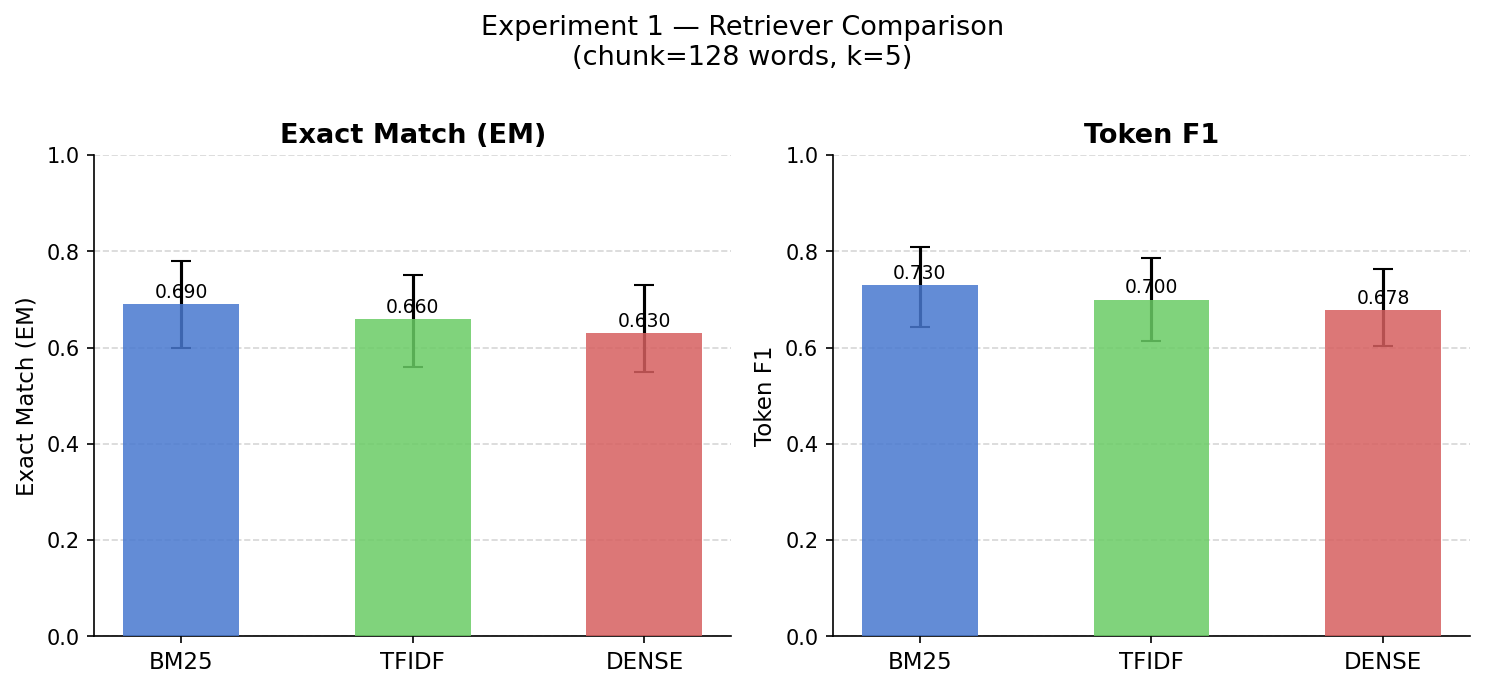

In [110]:
def fig1_retriever_comparison():
    data = _load_summary("exp1_summary")
    if data is None:
        return
    results = data["results"]
    rtypes  = list(results.keys())
    colors  = [PALETTE.get(r, "#888888") for r in rtypes]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match (EM)", "Token F1"]):
        means  = [results[r][metric]["mean"] for r in rtypes]
        lows   = [results[r][metric]["lo"]   for r in rtypes]
        highs  = [results[r][metric]["hi"]   for r in rtypes]
        labels = [r.upper() for r in rtypes]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 1 — Retriever Comparison\n"
        f"(chunk={config.DEFAULT_CHUNK_SIZE} words, k={config.DEFAULT_K})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _savefig("fig1_retriever_comparison.png")
    plt.show()


fig1_retriever_comparison()


02:15:27 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig2_chunk_size.png


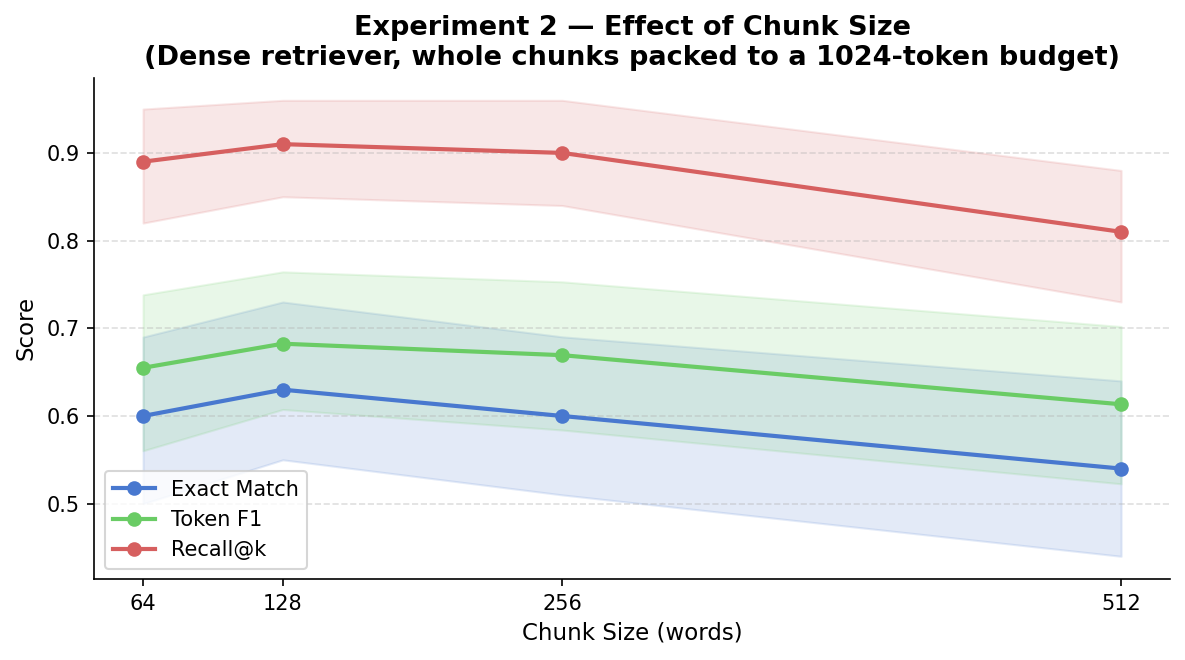

In [111]:
def fig2_chunk_size():
    data = _load_summary("exp2_summary")
    if data is None:
        return
    results = data["results"]

    sizes   = sorted(int(k) for k in results.keys())
    metrics = ["em", "f1", "recall_at_k"]
    labels  = ["Exact Match", "Token F1", "Recall@k"]
    colors  = ["#4878CF", "#6ACC65", "#D65F5F"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric, label, color in zip(metrics, labels, colors):
        means = [results[str(s)][metric]["mean"] for s in sizes]
        lows  = [results[str(s)][metric]["lo"]   for s in sizes]
        highs = [results[str(s)][metric]["hi"]   for s in sizes]
        ax.plot(sizes, means, marker="o", label=label, color=color, linewidth=2)
        ax.fill_between(sizes, lows, highs, alpha=0.15, color=color)

    ax.set_xlabel("Chunk Size (words)", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(
        "Experiment 2 — Effect of Chunk Size\n"
        f"(Dense retriever, whole chunks packed to a "
        f"{config.MAX_INPUT_TOKENS}-token budget)",
        fontsize=13, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_xticks(sizes)
    plt.tight_layout()
    _savefig("fig2_chunk_size.png")
    plt.show()


fig2_chunk_size()


02:15:28 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig3_k_values.png


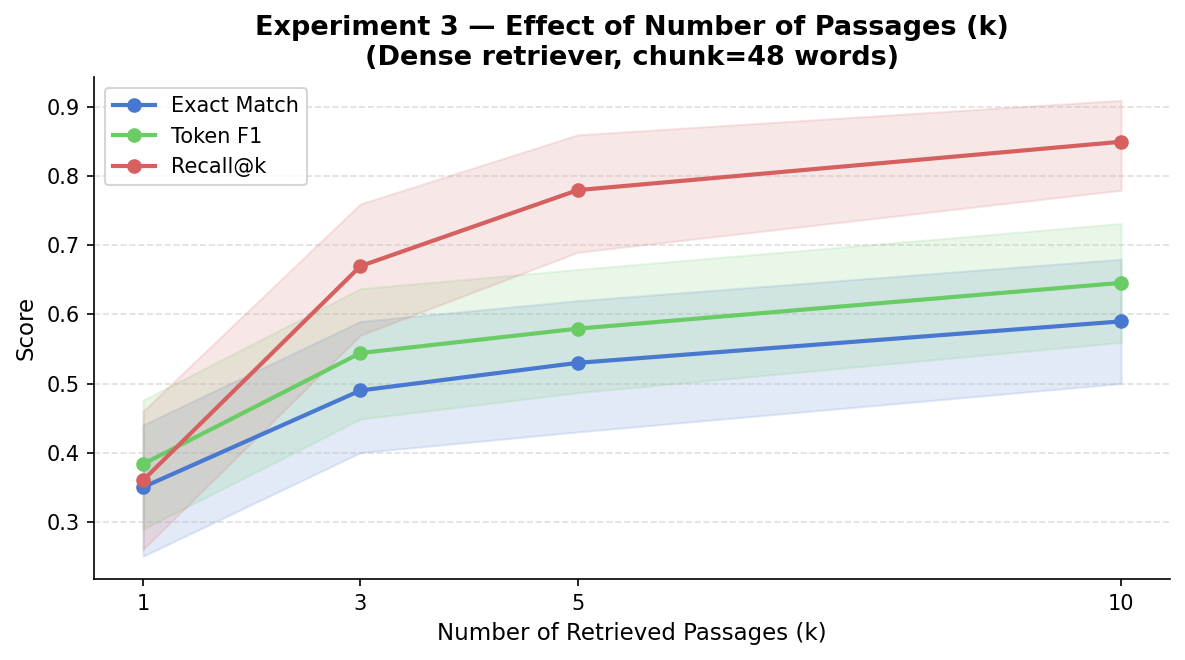

In [112]:
def fig3_k_values():
    data = _load_summary("exp3_summary")
    if data is None:
        return
    results = data["results"]

    ks      = sorted(int(k) for k in results.keys())
    metrics = ["em", "f1", "recall_at_k"]
    labels  = ["Exact Match", "Token F1", "Recall@k"]
    colors  = ["#4878CF", "#6ACC65", "#D65F5F"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric, label, color in zip(metrics, labels, colors):
        means = [results[str(k)][metric]["mean"] for k in ks]
        lows  = [results[str(k)][metric]["lo"]   for k in ks]
        highs = [results[str(k)][metric]["hi"]   for k in ks]
        ax.plot(ks, means, marker="o", label=label, color=color, linewidth=2)
        ax.fill_between(ks, lows, highs, alpha=0.15, color=color)

    ax.set_xlabel("Number of Retrieved Passages (k)", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(
        "Experiment 3 — Effect of Number of Passages (k)\n"
        f"(Dense retriever, chunk={config.EXP3_CHUNK_SIZE} words)",
        fontsize=13, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_xticks(ks)
    plt.tight_layout()
    _savefig("fig3_k_values.png")
    plt.show()


fig3_k_values()


02:15:28 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig4_prompt_template.png


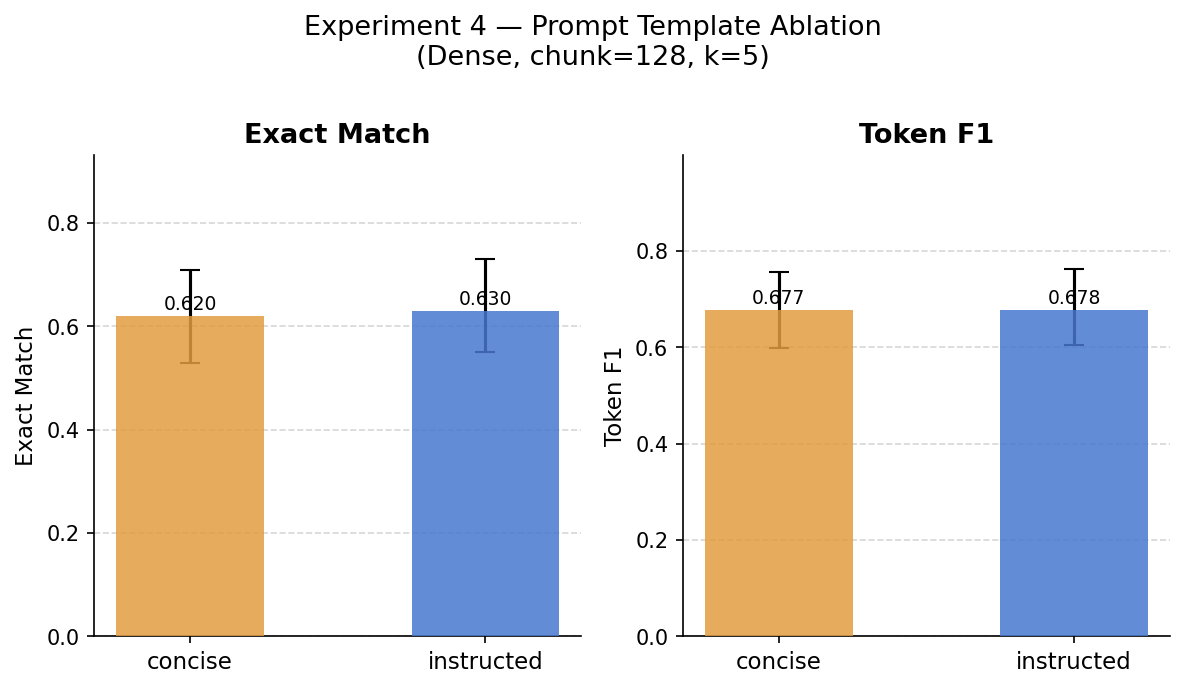

In [113]:
def fig4_prompt_template():
    data = _load_summary("exp4_summary")
    if data is None:
        return
    results = data["results"]

    templates = ["concise", "instructed"]
    colors    = [PALETTE[t] for t in templates]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match", "Token F1"]):
        means = [results[t][metric]["mean"] for t in templates]
        lows  = [results[t][metric]["lo"]   for t in templates]
        highs = [results[t][metric]["hi"]   for t in templates]
        _bar_with_ci(ax, templates, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 4 — Prompt Template Ablation\n"
        f"(Dense, chunk={config.DEFAULT_CHUNK_SIZE}, k={config.DEFAULT_K})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _savefig("fig4_prompt_template.png")
    plt.show()


fig4_prompt_template()


02:15:29 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig5_rag_vs_no_rag.png


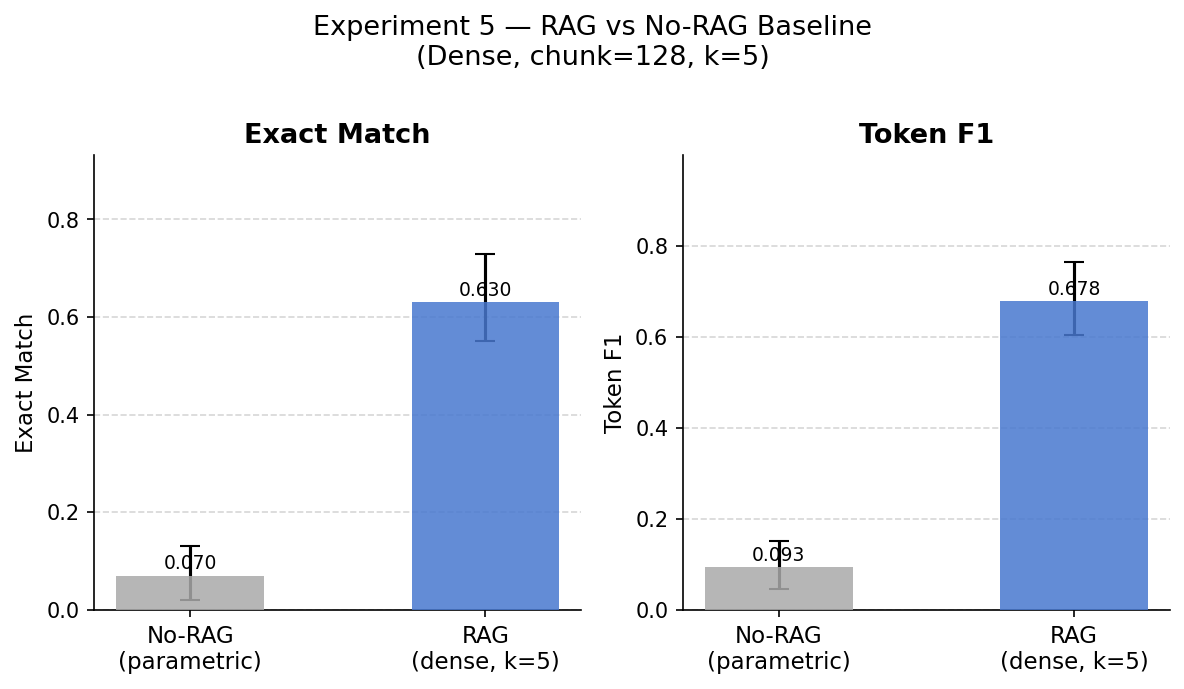

In [114]:
def fig5_rag_vs_no_rag():
    data = _load_summary("exp5_summary")
    if data is None:
        return

    conditions = ["no_rag", "rag"]
    labels     = ["No-RAG\n(parametric)", "RAG\n(dense, k=5)"]
    colors     = [PALETTE[c] for c in conditions]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match", "Token F1"]):
        means = [data[c][metric]["mean"] for c in conditions]
        lows  = [data[c][metric]["lo"]   for c in conditions]
        highs = [data[c][metric]["hi"]   for c in conditions]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 5 — RAG vs No-RAG Baseline\n"
        f"(Dense, chunk={config.DEFAULT_CHUNK_SIZE}, k={config.DEFAULT_K})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    _savefig("fig5_rag_vs_no_rag.png")
    plt.show()


fig5_rag_vs_no_rag()


02:15:32 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig6_error_analysis.png


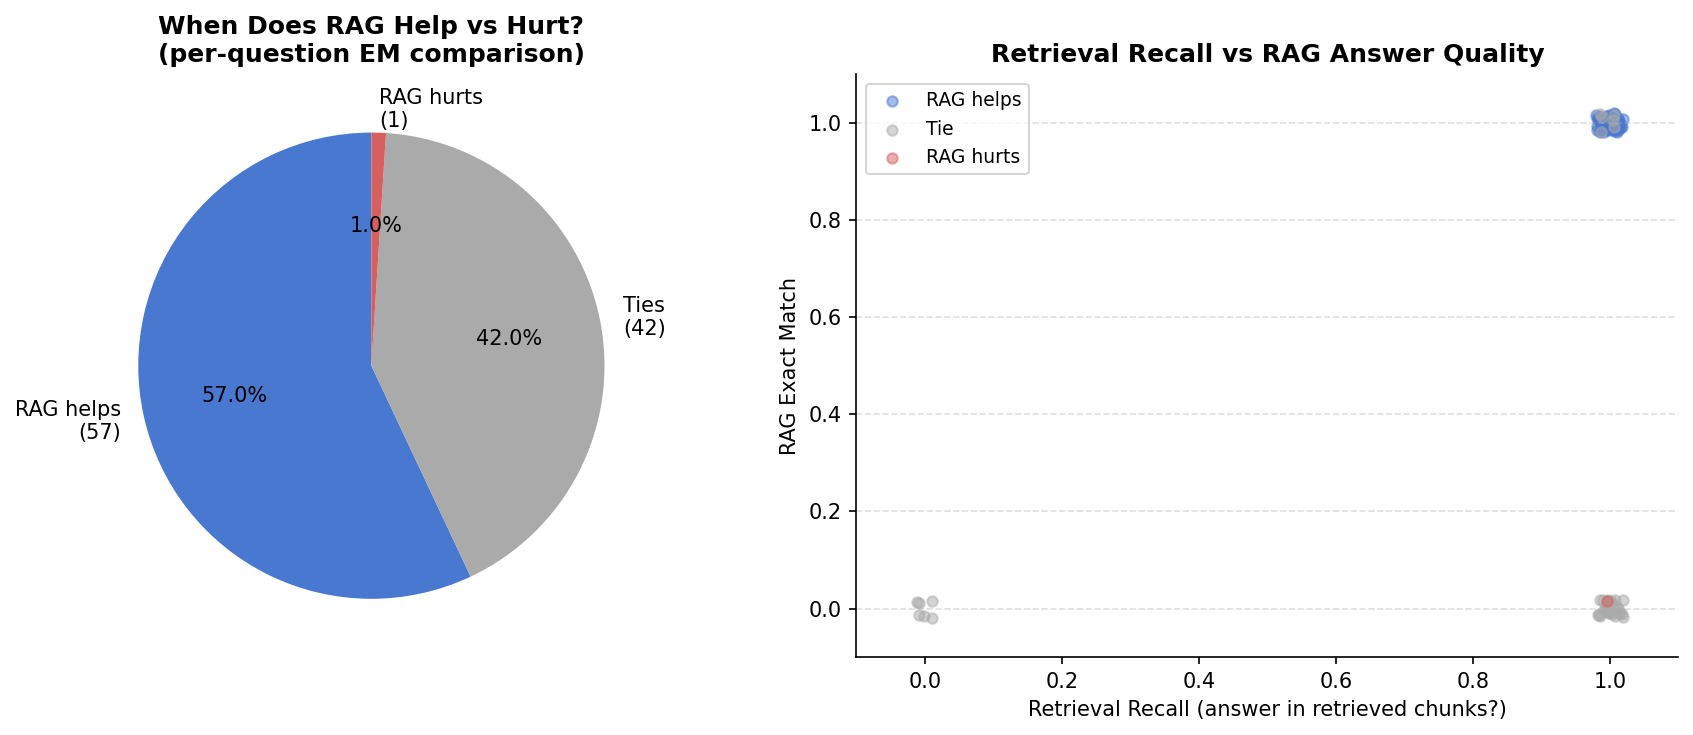

In [115]:
def fig6_error_analysis():
    data = _load_summary("exp5_summary")
    if data is None:
        return

    delta = data.get("delta_analysis", [])
    if not delta:
        logger.warning("No delta_analysis in exp5_summary — skipping fig6.")
        return

    helps = data["delta_counts"]["helps"]
    hurts = data["delta_counts"]["hurts"]
    ties  = data["delta_counts"]["ties"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: win/loss/tie pie
    ax = axes[0]
    wedge_labels = [f"RAG helps\n({helps})", f"Ties\n({ties})", f"RAG hurts\n({hurts})"]
    wedge_sizes  = [helps, ties, hurts]
    wedge_colors = ["#4878CF", "#AAAAAA", "#D65F5F"]
    ax.pie(
        wedge_sizes, labels=wedge_labels, colors=wedge_colors,
        autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10},
    )
    ax.set_title("When Does RAG Help vs Hurt?\n(per-question EM comparison)",
                 fontsize=12, fontweight="bold")

    # Right: recall vs EM scatter
    ax = axes[1]
    recalls = [d["recall"]   for d in delta]
    rag_ems = [d["rag_em"]   for d in delta]
    helps_mask = [d["rag_helps"] for d in delta]
    hurts_mask = [d["rag_hurts"] for d in delta]
    ties_mask  = [1 - d["rag_helps"] - d["rag_hurts"] for d in delta]

    rng = np.random.default_rng(42)
    jitter_x = rng.uniform(-0.02, 0.02, len(delta))
    jitter_y = rng.uniform(-0.02, 0.02, len(delta))
    recalls_j = np.array(recalls, dtype=float) + jitter_x
    rag_ems_j = np.array(rag_ems,  dtype=float) + jitter_y

    for mask, color, label in [
        (helps_mask, "#4878CF", "RAG helps"),
        (ties_mask,  "#AAAAAA", "Tie"),
        (hurts_mask, "#D65F5F", "RAG hurts"),
    ]:
        idx = [i for i, m in enumerate(mask) if m]
        if idx:
            ax.scatter(recalls_j[idx], rag_ems_j[idx],
                       c=color, alpha=0.5, s=25, label=label)

    ax.set_xlabel("Retrieval Recall (answer in retrieved chunks?)", fontsize=10)
    ax.set_ylabel("RAG Exact Match", fontsize=10)
    ax.set_title("Retrieval Recall vs RAG Answer Quality",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    _savefig("fig6_error_analysis.png")
    plt.show()


fig6_error_analysis()


02:15:33 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig7_qualitative.png


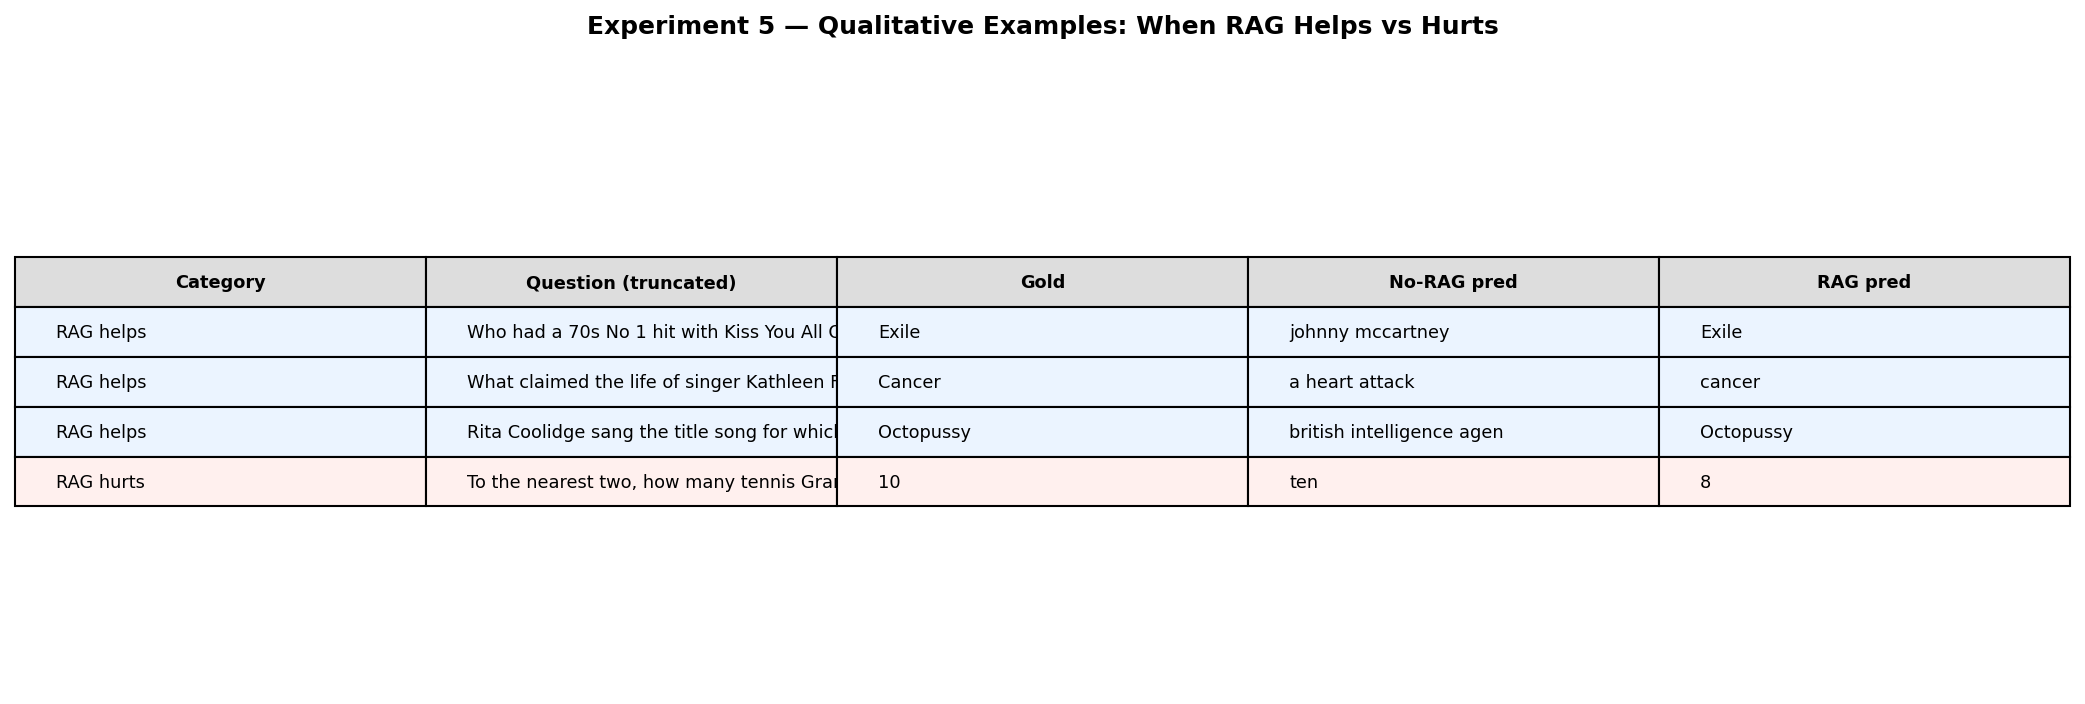

In [116]:
def fig7_qualitative():
    data = _load_summary("exp5_summary")
    if data is None:
        return

    delta = data.get("delta_analysis", [])
    if not delta:
        return

    helps_cases = [d for d in delta if d["rag_helps"] == 1 and d["recall"] == 1.0][:3]
    hurts_cases = [d for d in delta if d["rag_hurts"] == 1][:3]

    fig, ax = plt.subplots(
        figsize=(14, max(4, (len(helps_cases) + len(hurts_cases)) * 1.2))
    )
    ax.axis("off")

    col_labels = ["Category", "Question (truncated)", "Gold",
                  "No-RAG pred", "RAG pred"]
    rows = []
    for d in helps_cases:
        rows.append([
            "RAG helps",
            d["question"][:55] + ("…" if len(d["question"]) > 55 else ""),
            str(d["gold"][0])[:25],
            str(d["no_rag_pred"])[:25],
            str(d["rag_pred"])[:25],
        ])
    for d in hurts_cases:
        rows.append([
            "RAG hurts",
            d["question"][:55] + ("…" if len(d["question"]) > 55 else ""),
            str(d["gold"][0])[:25],
            str(d["no_rag_pred"])[:25],
            str(d["rag_pred"])[:25],
        ])

    if not rows:
        logger.info("Not enough examples for qualitative figure — skipping.")
        plt.close()
        return

    tbl = ax.table(
        cellText=rows, colLabels=col_labels, cellLoc="left", loc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.8)

    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor("#DDDDDD")
            cell.set_text_props(fontweight="bold")
        elif row <= len(helps_cases):
            cell.set_facecolor("#EBF4FF")
        else:
            cell.set_facecolor("#FFF0EE")

    ax.set_title(
        "Experiment 5 — Qualitative Examples: When RAG Helps vs Hurts",
        fontsize=12, fontweight="bold", pad=20,
    )
    plt.tight_layout()
    _savefig("fig7_qualitative.png")
    plt.show()


fig7_qualitative()


02:15:34 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig8_oracle.png


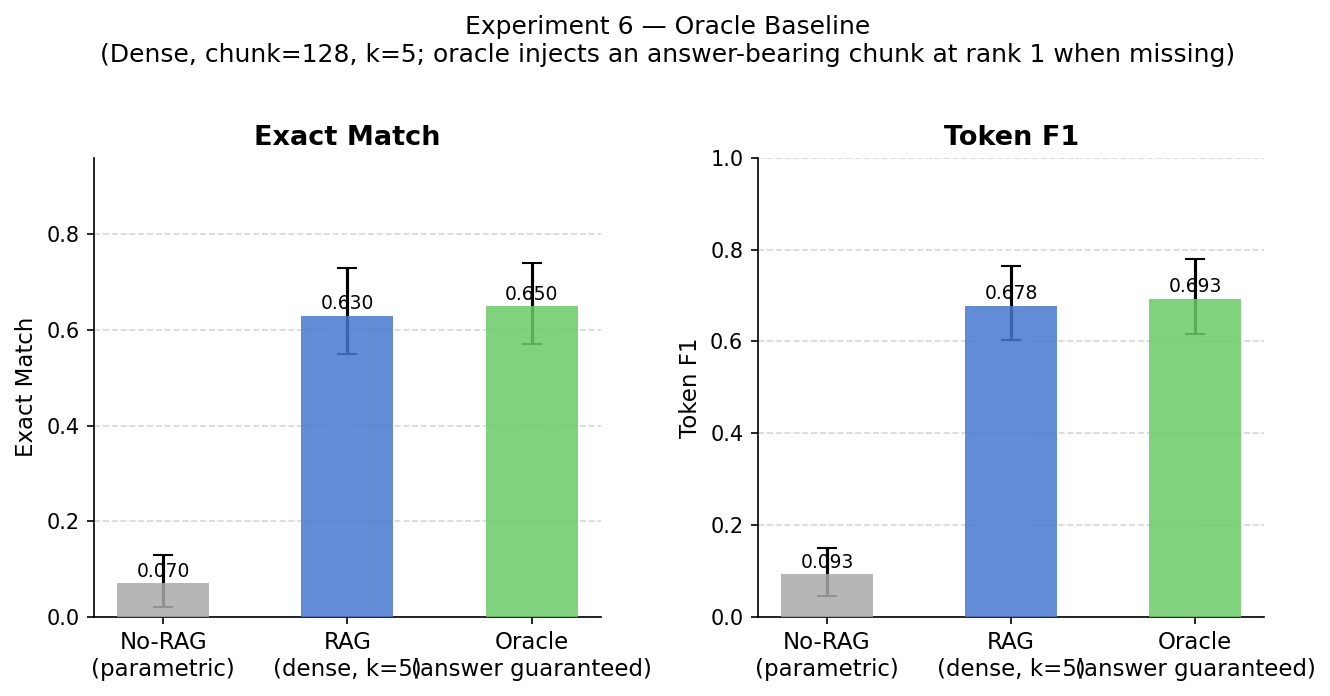

In [117]:
def fig8_oracle():
    """No-RAG vs RAG vs Oracle bars (EM + F1)."""
    rag_data    = _load_summary("exp5_summary")
    oracle_data = _load_summary("exp6_oracle")
    if rag_data is None or oracle_data is None:
        return

    conditions = ["no_rag", "rag", "oracle"]
    labels     = ["No-RAG\n(parametric)", "RAG\n(dense, k=5)",
                  "Oracle\n(answer guaranteed)"]
    colors     = ["#AAAAAA", "#4878CF", "#6ACC65"]
    cond_data  = {
        "no_rag": rag_data["no_rag"],
        "rag":    rag_data["rag"],
        "oracle": oracle_data["metrics"],
    }

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match", "Token F1"]):
        means = [cond_data[c][metric]["mean"] for c in conditions]
        lows  = [cond_data[c][metric]["lo"]   for c in conditions]
        highs = [cond_data[c][metric]["hi"]   for c in conditions]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 6 — Oracle Baseline\n"
        f"(Dense, chunk={config.DEFAULT_CHUNK_SIZE}, k={config.DEFAULT_K}; "
        "oracle injects an answer-bearing chunk at rank 1 when missing)",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    _savefig("fig8_oracle.png")
    plt.show()


fig8_oracle()


02:15:35 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig9_rerank.png


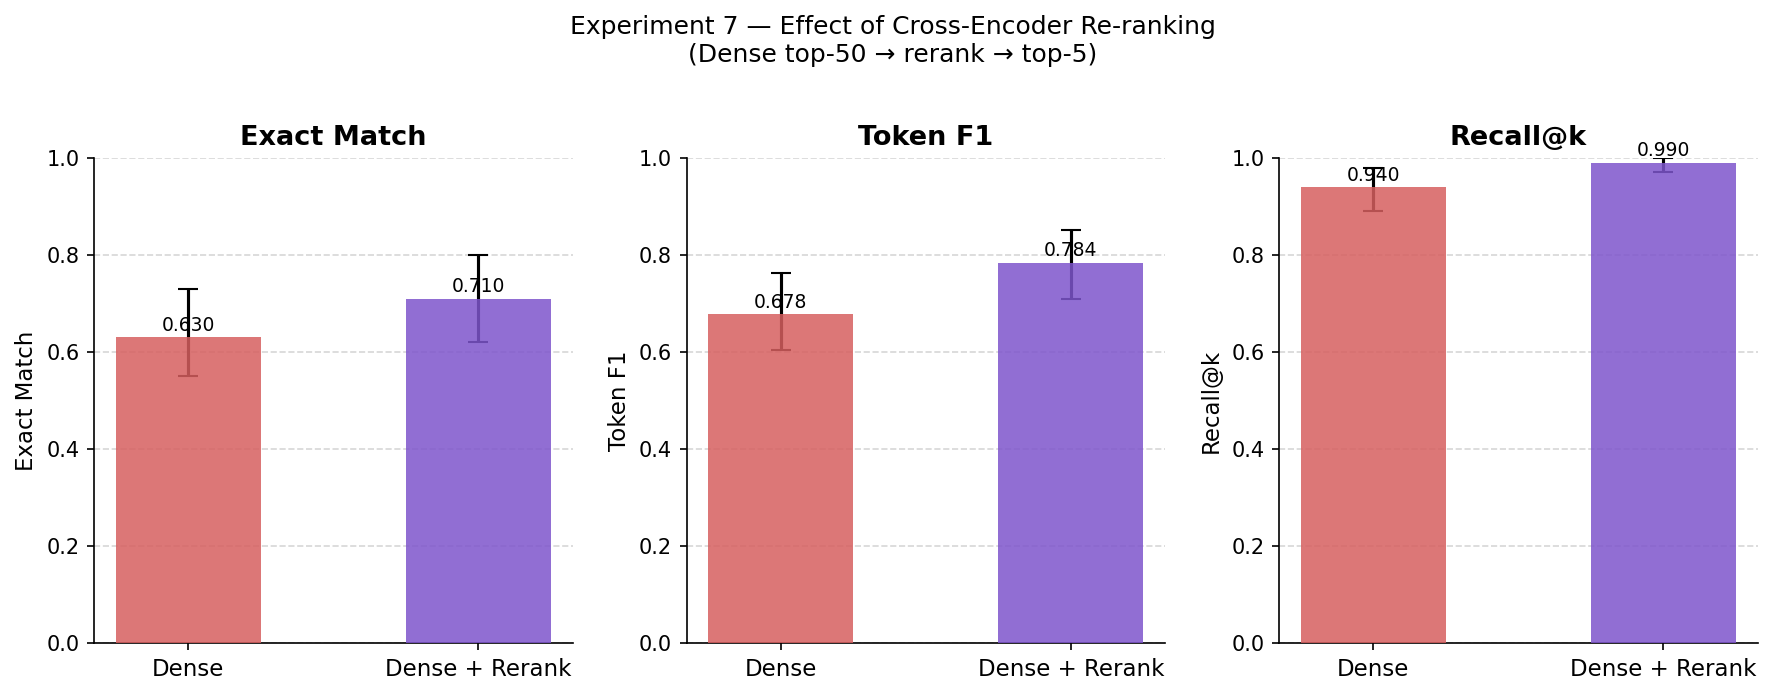

In [118]:
def fig9_rerank():
    """Compare dense (top-5) vs dense+rerank (top-5 of top-50)."""
    base = _load_summary("exp7_dense_base")
    exp7 = _load_summary("exp7_rerank")
    if base is None or exp7 is None:
        return

    dense_metrics  = base["metrics"]
    rerank_metrics = exp7["metrics"]

    labels = ["e5 Dense", "e5 Dense + Rerank"]
    colors = ["#D65F5F", "#7E55CC"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
    for ax, metric, full_name in zip(
        axes, ["em", "f1", "recall_at_k"],
        ["Exact Match", "Token F1", "Recall@k"],
    ):
        d = dense_metrics.get(metric, {})
        r = rerank_metrics.get(metric, {})
        means = [d.get("mean", 0), r.get("mean", 0)]
        lows  = [d.get("lo",   0), r.get("lo",   0)]
        highs = [d.get("hi",   0), r.get("hi",   0)]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 7 — Effect of Cross-Encoder Re-ranking\n"
        f"(e5 dense top-{config.RERANK_TOP_N} → rerank → top-{config.DEFAULT_K})",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    _savefig("fig9_rerank.png")
    plt.show()


fig9_rerank()


02:15:35 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig10_distractor_sweep.png


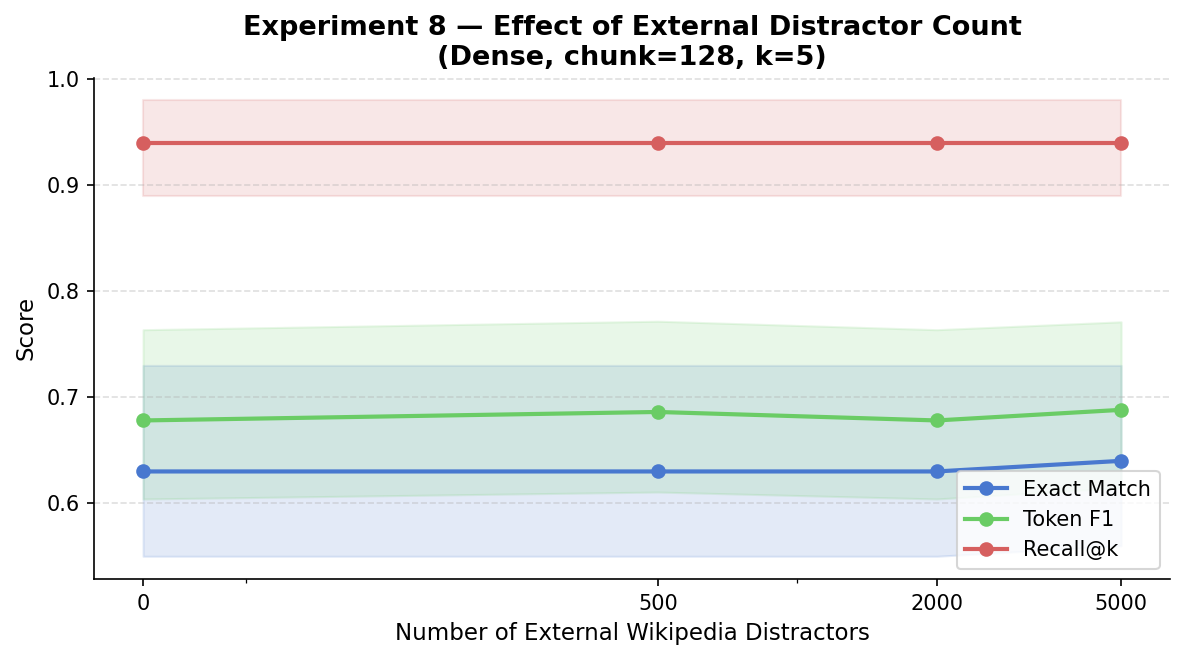

In [119]:
def fig10_distractor_sweep():
    """EM / F1 / Recall@k as a function of the external-distractor count."""
    data = _load_summary("exp8_summary")
    if data is None:
        return
    results = data["results"]
    ns = sorted(int(k) for k in results.keys())
    if not ns:
        return

    metrics = ["em", "f1", "recall_at_k"]
    labels  = ["Exact Match", "Token F1", "Recall@k"]
    colors  = ["#4878CF", "#6ACC65", "#D65F5F"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric, label, color in zip(metrics, labels, colors):
        means = [results[str(n)]["metrics"][metric]["mean"] for n in ns]
        lows  = [results[str(n)]["metrics"][metric]["lo"]   for n in ns]
        highs = [results[str(n)]["metrics"][metric]["hi"]   for n in ns]
        ax.plot(ns, means, marker="o", label=label, color=color, linewidth=2)
        ax.fill_between(ns, lows, highs, alpha=0.15, color=color)

    ax.set_xscale("symlog", linthresh=500)
    ax.set_xlabel("Number of External Wikipedia Distractors", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(
        "Experiment 8 — Effect of External Distractor Count\n"
        f"(Dense, chunk={config.DEFAULT_CHUNK_SIZE}, k={config.DEFAULT_K})",
        fontsize=13, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_xticks(ns)
    ax.set_xticklabels([str(n) for n in ns])
    plt.tight_layout()
    _savefig("fig10_distractor_sweep.png")
    plt.show()


fig10_distractor_sweep()


02:15:36 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig11_distraction.png


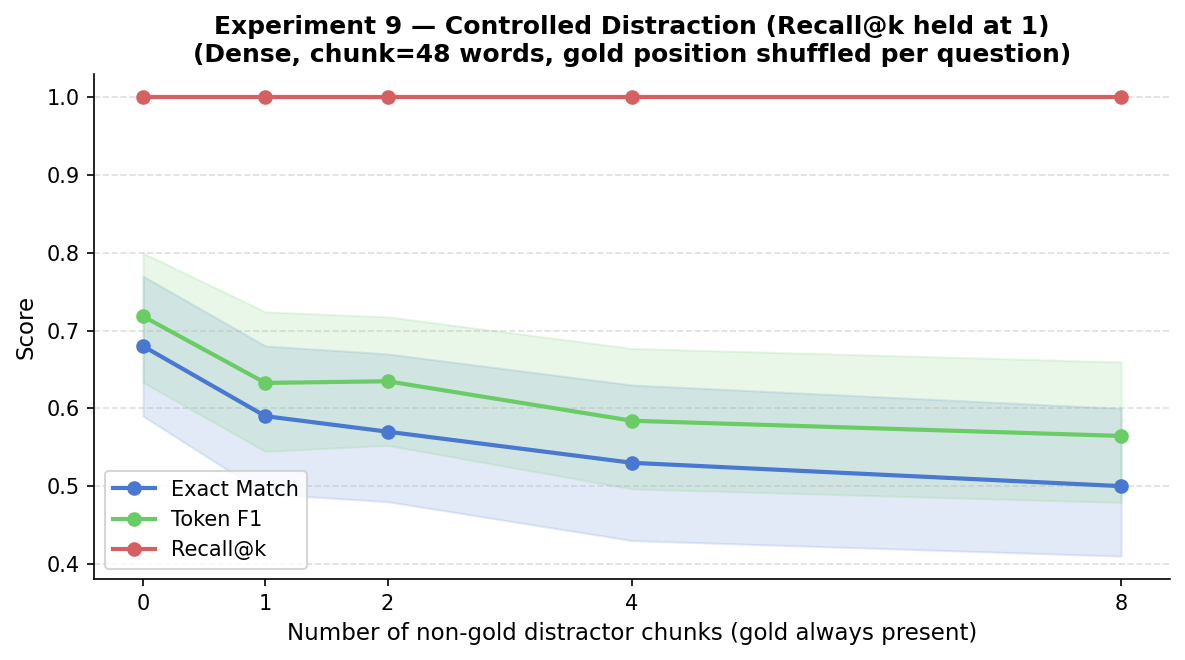

In [120]:
def fig11_distraction():
    """EM / F1 / Recall@k vs number of non-gold distractors (Exp 9)."""
    data = _load_summary("exp9_summary")
    if data is None:
        return
    results = data["results"]
    ns = sorted(int(k) for k in results.keys())
    if not ns:
        return

    metrics = ["em", "f1", "recall_at_k"]
    labels  = ["Exact Match", "Token F1", "Recall@k"]
    colors  = ["#4878CF", "#6ACC65", "#D65F5F"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for metric, label, color in zip(metrics, labels, colors):
        means = [results[str(n)][metric]["mean"] for n in ns]
        lows  = [results[str(n)][metric]["lo"]   for n in ns]
        highs = [results[str(n)][metric]["hi"]   for n in ns]
        ax.plot(ns, means, marker="o", label=label, color=color, linewidth=2)
        ax.fill_between(ns, lows, highs, alpha=0.15, color=color)

    ax.set_xlabel("Number of non-gold distractor chunks (gold always present)",
                  fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(
        "Experiment 9 — Controlled Distraction (Recall@k held at 1)\n"
        f"(Dense, chunk={config.EXP3_CHUNK_SIZE} words, gold fixed at first position)",
        fontsize=12, fontweight="bold",
    )
    ax.legend(fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.set_xticks(ns)
    plt.tight_layout()
    _savefig("fig11_distraction.png")
    plt.show()


fig11_distraction()


In [ ]:
def fig14_forced_miss():
    """No-RAG vs Forced-miss vs RAG bars (EM + F1) — Experiment 11."""
    rag_data = _load_summary("exp5_summary")
    fm       = _load_summary("exp11_forced_miss")
    if rag_data is None or fm is None:
        return

    conditions = ["no_rag", "forced_miss", "rag"]
    labels     = ["No-RAG\n(parametric)", "Forced miss\n(non-gold ctx)",
                  "RAG\n(dense, k=5)"]
    colors     = ["#AAAAAA", "#D65F5F", "#4878CF"]
    cond_data  = {
        "no_rag":      rag_data["no_rag"],
        "rag":         rag_data["rag"],
        "forced_miss": fm["metrics"],
    }

    fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
    for ax, metric, full_name in zip(axes, ["em", "f1"],
                                     ["Exact Match", "Token F1"]):
        means = [cond_data[c][metric]["mean"] for c in conditions]
        lows  = [cond_data[c][metric]["lo"]   for c in conditions]
        highs = [cond_data[c][metric]["hi"]   for c in conditions]
        _bar_with_ci(ax, labels, means, lows, highs, colors,
                     title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 11 — Forced Retrieval Miss (recall = 0)\n"
        f"(Dense, chunk={config.EXP3_CHUNK_SIZE} words, only non-gold chunks "
        "vs the No-RAG floor)",
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    _savefig("fig14_forced_miss.png")
    plt.show()


fig14_forced_miss()


02:15:37 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig13_embedding_models.png


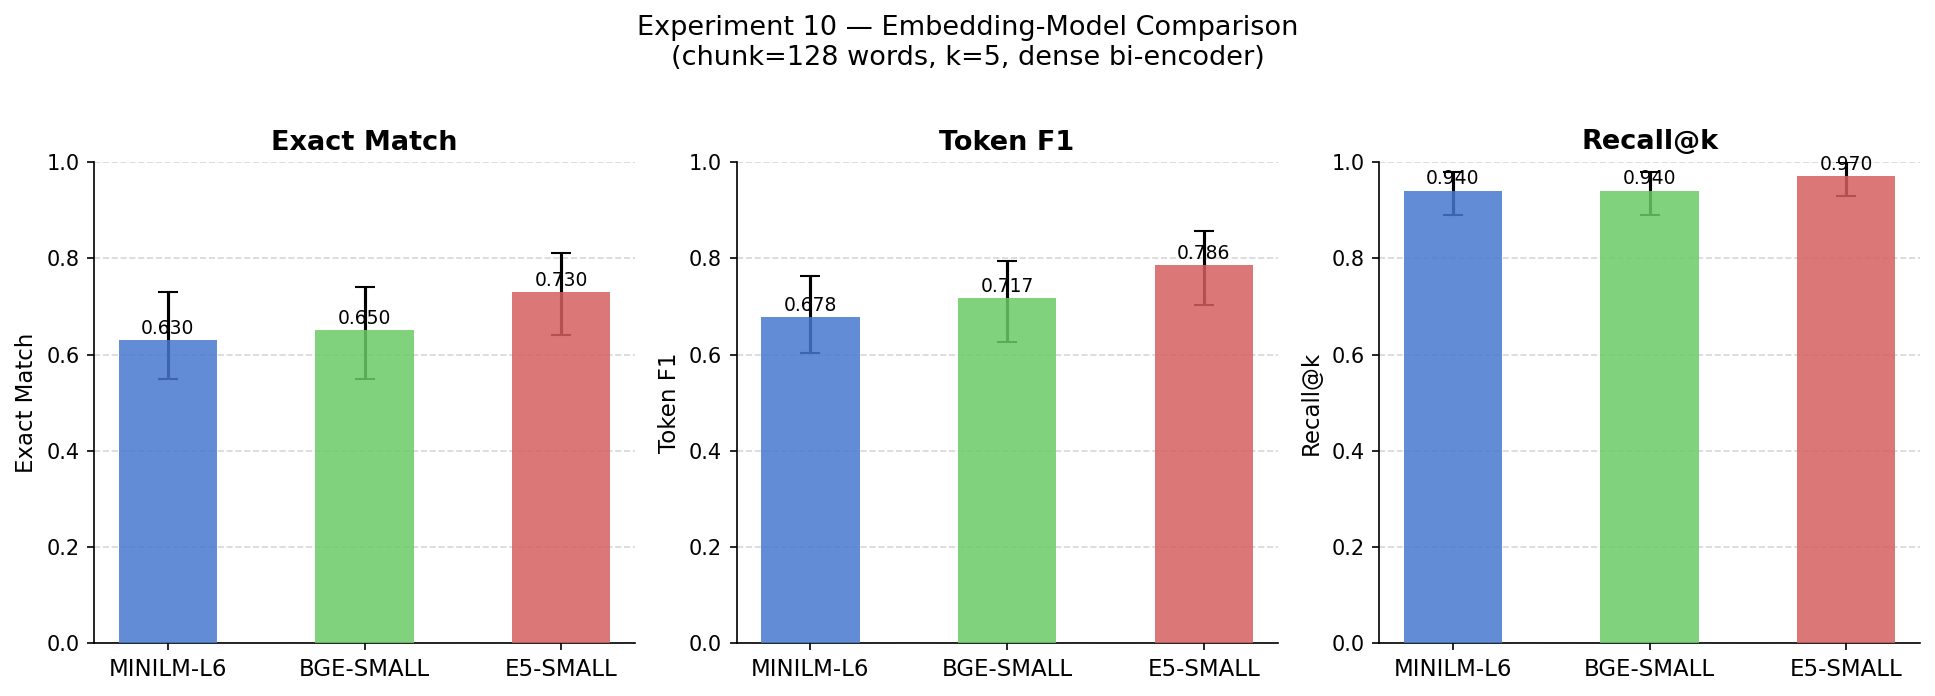

In [121]:
def fig13_embedding_models():
    """EM / F1 / Recall@k across dense embedding models (Exp 10)."""
    data = _load_summary("exp10_summary")
    if data is None:
        return
    results = data["results"]
    labels_k = list(results.keys())
    if not labels_k:
        return
    palette = ["#4878CF", "#6ACC65", "#D65F5F", "#7E55CC", "#E29C3F"]
    colors = [palette[i % len(palette)] for i in range(len(labels_k))]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ax, metric, full_name in zip(
        axes, ["em", "f1", "recall_at_k"],
        ["Exact Match", "Token F1", "Recall@k"],
    ):
        means = [results[l][metric]["mean"] for l in labels_k]
        lows  = [results[l][metric]["lo"]   for l in labels_k]
        highs = [results[l][metric]["hi"]   for l in labels_k]
        _bar_with_ci(ax, [l.upper() for l in labels_k], means, lows, highs,
                     colors, title=full_name, ylabel=full_name)

    fig.suptitle(
        "Experiment 10 — Embedding-Model Comparison\n"
        f"(chunk={config.DEFAULT_CHUNK_SIZE} words, k={config.DEFAULT_K}, "
        "dense bi-encoder)",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    _savefig("fig13_embedding_models.png")
    plt.show()


fig13_embedding_models()


02:15:38 [INFO] rag_project — Saved → c:\Users\Filip\Documents\ml-project\RAG_ML\figures\fig12_significance.png


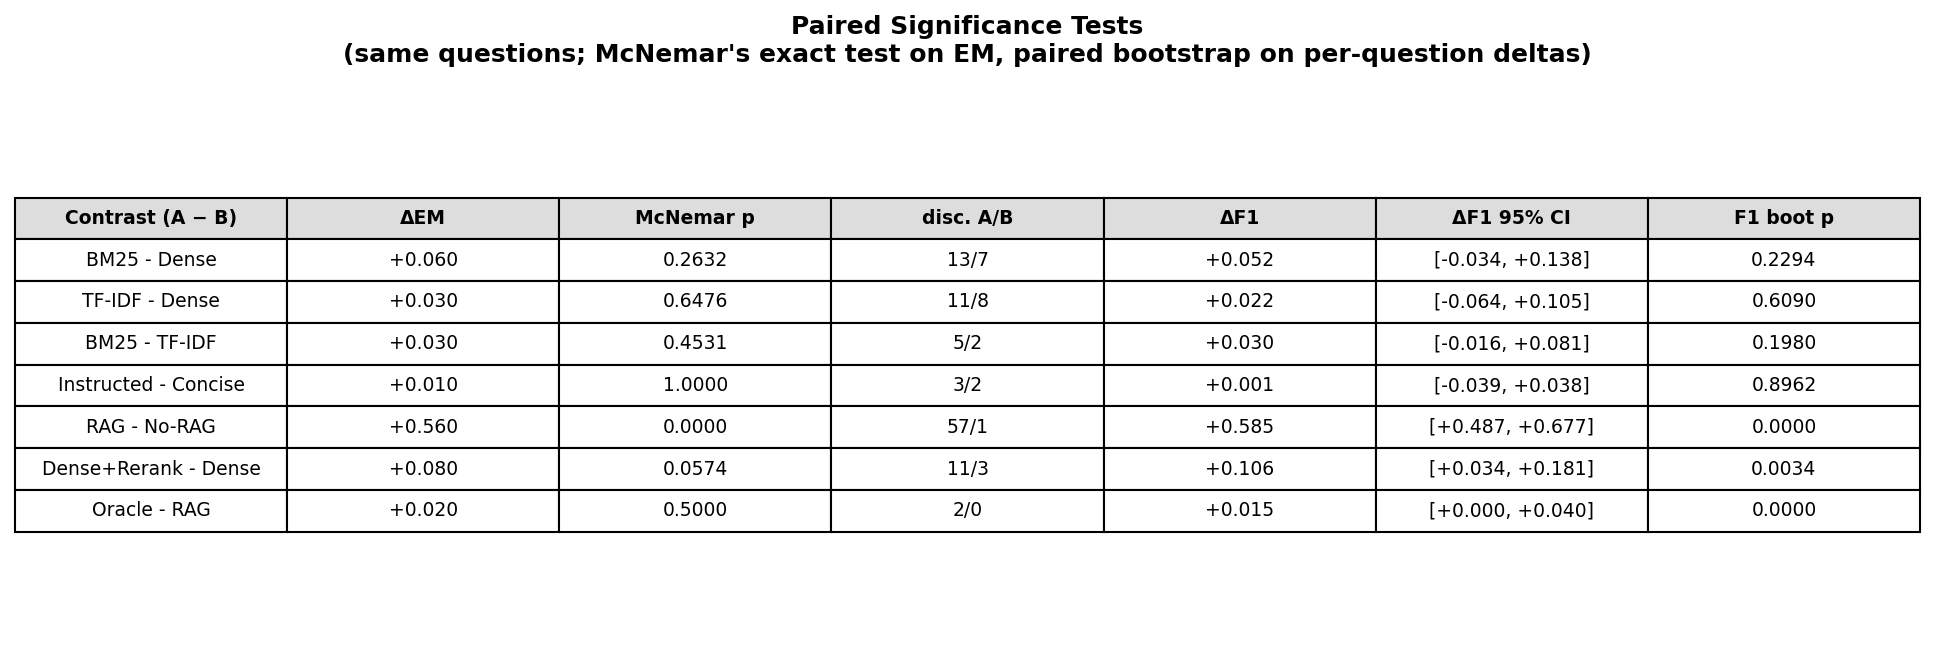

In [122]:
def fig12_significance():
    """Table of paired significance tests (McNemar on EM, paired bootstrap)."""
    data = _load_summary("paired_significance")
    if data is None:
        return
    contrasts = data.get("contrasts", [])
    if not contrasts:
        return

    col_labels = ["Contrast (A − B)", "ΔEM", "McNemar p",
                  "disc. A/B", "ΔF1", "ΔF1 95% CI", "F1 boot p"]
    rows = []
    for c in contrasts:
        em, dem, df1 = (c["em_mcnemar"], c["em_paired_bootstrap"],
                        c["f1_paired_bootstrap"])
        rows.append([
            c["contrast"],
            f"{dem['mean_delta']:+.3f}",
            f"{em['p_value']:.4f}",
            f"{em['a_only']}/{em['b_only']}",
            f"{df1['mean_delta']:+.3f}",
            f"[{df1['lo']:+.3f}, {df1['hi']:+.3f}]",
            f"{df1['p_value']:.4f}",
        ])

    fig, ax = plt.subplots(figsize=(13, 0.9 + 0.5 * len(rows)))
    ax.axis("off")
    tbl = ax.table(cellText=rows, colLabels=col_labels,
                   cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    for (r, _col), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#DDDDDD")
            cell.set_text_props(fontweight="bold")
    ax.set_title(
        "Paired Significance Tests\n"
        "(same questions; McNemar's exact test on EM, paired bootstrap on per-question deltas)",
        fontsize=12, fontweight="bold", pad=18,
    )
    plt.tight_layout()
    _savefig("fig12_significance.png")
    plt.show()


fig12_significance()


# Send me a notification when it stops running

In [123]:
import requests
requests.post("https://ntfy.sh/zwembad-alert",data="notebook finished running")

<Response [200]>